# Exploratory Data Analysis - CBIS-DDSM Mass Cases

**Chollet Workflow Stages 1-3**

This notebook explores the CBIS-DDSM **mass** training and test sets - calcification cases are outside the scope of this study. The goal is to understand class distribution, patient coverage, view availability, and image characteristics before any modelling work begins.

**Dataset references:**

Lee, R., Gimenez, F., Hoogi, A., Miyake, K. K., Gorovoy, M. & Rubin, D. L. (2017). A curated mammography data set for use in computer-aided detection and diagnosis research. *Scientific Data*, 4, 170177. https://doi.org/10.1038/sdata.2017.177

Wang, L. (2024). Mammography with deep learning for breast cancer detection. *Frontiers in Oncology*, 14, 1281922. https://doi.org/10.3389/fonc.2024.1281922

Chollet, F. (2018). *Deep Learning with Python*. Manning.

American College of Radiology (2013). *ACR BI-RADS Atlas: Breast Imaging Reporting and Data System* (5th ed.). American College of Radiology.

NHS England (2022). *Breast Screening Programme, England 2019-20*. NHS Digital.

McKinney, S. M. et al. (2020). International evaluation of an AI system for breast cancer screening. *Nature*, 577, 89-94.

---

## Notebook structure

| Section | Purpose |
|---|---|
| 0. Setup | Seeds, paths, imports |
| 1. Load & inspect | CSV shape, columns, dtypes |
| 2. Missing values | Identify gaps; duplicate image paths |
| 3. Patient-level leakage check | Verify train/test patients are disjoint |
| 4. Class distribution | Label balance; BENIGN_WITHOUT_CALLBACK analysis; real-world prevalence enrichment |
| 5. Clinical features | Mass shape, margins, assessment, subtlety — chi-square + Cramér's V + Mann-Whitney U |
| 5b. Breast density | ACR density distribution; association with malignancy; Phase 9 stratification note |
| 5c. BI-RADS clinical baseline | BI-RADS ROC curve; threshold sensitivity/specificity; radiologist-pathology discordance |
| 6. View coverage | CC / MLO availability; multi-view pairing structure for Phase 7 |
| 7. Sample images | Visual inspection with pathology labels |
| 8. DICOM metadata audit | Bit depth, photometric interpretation (full audit) |
| 9. Image resolution | Height/width distributions; resize justification |
| 10. Pixel intensity | Histogram; class-stratified statistics |
| 10a. Normalisation statistics | Training-set mean/std; normalisation decision; ImageNet constants |
| 10b. Augmentation preview | Visual confirmation of training augmentation pipeline |
| 11. EDA summary | Dataset characterisation; preprocessing implications |

## 0. Setup

Seeds are fixed here and must match across all notebooks in this project.
All paths and constants live in `CONFIG` - no magic numbers elsewhere in the notebook.

In [1]:
import os
import random
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pydicom
import scipy.ndimage as ndi
import seaborn as sns
from PIL import Image as _PIL_Image
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GroupShuffleSplit

SEED = 28
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

CONFIG = {
    "seed": SEED,
    "train_csv": Path("../data/raw/mass_case_description_train_set.csv"),
    "test_csv": Path("../data/raw/mass_case_description_test_set.csv"),
    "train_img_dir": Path("../data/raw/mass_train/images"),
    "test_img_dir": Path("../data/raw/mass_test/images"),
    "figures_dir": Path("../outputs/figures/eda"),
    "cat_cols": [
        "left or right breast",
        "image view",
        "pathology",
        "mass shape",
        "mass margins",
    ],
    "img_col": "image file path",
    "clinical_cols": ["mass shape", "mass margins", "assessment", "subtlety"],
    "valid_views": ["CC", "MLO"],
    "target_size": (224, 224),
}

# Validate paths exist before any downstream cell can fail silently
for _key in ("train_csv", "test_csv", "train_img_dir", "test_img_dir"):
    assert CONFIG[
        _key
    ].exists(), f"Expected path not found - CONFIG['{_key}']: {CONFIG[_key]}"

CONFIG["figures_dir"].mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 100,
        "figure.figsize": (10, 6),
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "savefig.bbox": "tight",
        "savefig.dpi": 150,
    }
)

print(f"numpy {np.__version__}")
print(f"pandas {pd.__version__}")
print(f"pydicom {pydicom.__version__}")

numpy 1.26.4
pandas 3.0.2
pydicom 3.0.2


## 1. Load & inspect

### Problem definition (Chollet, 2018, Ch. 4)

- **Input**: A single mammogram image (DICOM), representing one view of one breast.
- **Output**: A binary label - malignant (1) or benign/BENIGN_WITHOUT_CALLBACK (0).
- **Task type**: Binary image classification.
- **Why this framing is appropriate**: The unit of analysis is the mammogram image, but the unit of independence is the patient. Multiple rows in the DDSM CSV may share a patient_id. Patient-level stratification is therefore mandatory at the splitting stage to prevent data leakage (Chollet, 2018, Ch. 4).
- **Scope**: Mass cases only. Calcification cases are excluded.

In [2]:
train_df = pd.read_csv(CONFIG["train_csv"])
test_df = pd.read_csv(CONFIG["test_csv"])

if set(train_df.columns) != set(test_df.columns):
    print("WARNING - column mismatch between train and test:")
    print("train only:", set(train_df.columns) - set(test_df.columns))
    print("test only: ", set(test_df.columns) - set(train_df.columns))

# Cast known categoricals (in-place mutation of both dataframes)
for col in CONFIG["cat_cols"]:
    for df in [train_df, test_df]:
        if col in df.columns:
            df[col] = df[col].astype("category")
        else:
            print(f"WARNING: expected column '{col}' not found")

train_df.info()
print(f"\nTest shape: {test_df.shape}")

print("\n--- First 5 rows (train) ---")
display(train_df.head())

print("\n--- First 5 rows (test) ---")
display(test_df.head())

print("\n--- Numeric summary (train) ---")
display(train_df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 1318 entries, 0 to 1317
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   patient_id               1318 non-null   str     
 1   breast_density           1318 non-null   int64   
 2   left or right breast     1318 non-null   category
 3   image view               1318 non-null   category
 4   abnormality id           1318 non-null   int64   
 5   abnormality type         1318 non-null   str     
 6   mass shape               1314 non-null   category
 7   mass margins             1275 non-null   category
 8   assessment               1318 non-null   int64   
 9   pathology                1318 non-null   category
 10  subtlety                 1318 non-null   int64   
 11  image file path          1318 non-null   str     
 12  cropped image file path  1318 non-null   str     
 13  ROI mask file path       1318 non-null   str     
dtypes: category(5), int

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....



--- First 5 rows (test) ---


,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00016,4,LEFT,CC,1,mass,IRREGULAR,SPICULATED,5,MALIGNANT,5,Mass-Test_P_00016_LEFT_CC/1.3.6.1.4.1.9590.100...,Mass-Test_P_00016_LEFT_CC_1/1.3.6.1.4.1.9590.1...,Mass-Test_P_00016_LEFT_CC_1/1.3.6.1.4.1.9590.1...
1,P_00016,4,LEFT,MLO,1,mass,IRREGULAR,SPICULATED,5,MALIGNANT,5,Mass-Test_P_00016_LEFT_MLO/1.3.6.1.4.1.9590.10...,Mass-Test_P_00016_LEFT_MLO_1/1.3.6.1.4.1.9590....,Mass-Test_P_00016_LEFT_MLO_1/1.3.6.1.4.1.9590....
2,P_00017,2,LEFT,CC,1,mass,ROUND,CIRCUMSCRIBED,4,MALIGNANT,4,Mass-Test_P_00017_LEFT_CC/1.3.6.1.4.1.9590.100...,Mass-Test_P_00017_LEFT_CC_1/1.3.6.1.4.1.9590.1...,Mass-Test_P_00017_LEFT_CC_1/1.3.6.1.4.1.9590.1...
3,P_00017,2,LEFT,MLO,1,mass,ROUND,ILL_DEFINED,4,MALIGNANT,4,Mass-Test_P_00017_LEFT_MLO/1.3.6.1.4.1.9590.10...,Mass-Test_P_00017_LEFT_MLO_1/1.3.6.1.4.1.9590....,Mass-Test_P_00017_LEFT_MLO_1/1.3.6.1.4.1.9590....
4,P_00032,3,RIGHT,CC,1,mass,ROUND,OBSCURED,0,BENIGN,2,Mass-Test_P_00032_RIGHT_CC/1.3.6.1.4.1.9590.10...,Mass-Test_P_00032_RIGHT_CC_1/1.3.6.1.4.1.9590....,Mass-Test_P_00032_RIGHT_CC_1/1.3.6.1.4.1.9590....



--- Numeric summary (train) ---


,breast_density,abnormality id,assessment,subtlety
count,1318.000000,1318.000000,1318.000000,1318.000000
mean,2.203338,1.116085,3.504552,3.965857
std,0.873774,0.467013,1.414609,1.102032
min,1.000000,1.000000,0.000000,0.000000
25%,2.000000,1.000000,3.000000,3.000000
50%,2.000000,1.000000,4.000000,4.000000
75%,3.000000,1.000000,4.000000,5.000000
max,4.000000,6.000000,5.000000,5.000000


## 2. Missing Values

### Missing values
`mass_margins` (43 train, 17 test) and `mass_shape` (4 train, 0 test) contain
missing values inherited from the original DDSM `.OVERLAY` files, in which
BI-RADS descriptors were not always recorded at the time of digitisation
(Lee et al., 2017). These gaps affect Section 5 clinical feature analysis only
- they do not impede the CNN pipeline since model input is the raw image.

### Duplicate image paths
87 training rows and 17 test rows share an image file path with at least one
other row. This is intentional dataset design: the `abnormality_id` column
exists precisely because a single mammogram may contain multiple distinct masses
(Lee et al., 2017). Of the 3,103 mammograms in the full CBIS-DDSM, 465 contain
more than one abnormality. `data_loader.py` must deduplicate on `image file path`
before constructing any image generator.

In [3]:
for label, df in [("Training", train_df), ("Test", test_df)]:
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    print(f"=== Missing Values - {label} Set ===")
    print(missing.to_string() if not missing.empty else "  No missing values")
    print()

IMG_COL = CONFIG["img_col"]

if IMG_COL in train_df.columns:
    n_dup_train = train_df[IMG_COL].dropna().duplicated().sum()
    n_dup_test = test_df[IMG_COL].dropna().duplicated().sum()
    print(f"Duplicate image paths - Train : {n_dup_train}")
    print(f"Duplicate image paths - Test  : {n_dup_test}")

    if n_dup_train > 0 or n_dup_test > 0:
        print("\nSample duplicate paths (training set):")
        dup_mask = train_df[IMG_COL].duplicated(keep=False)
        display(
            train_df[dup_mask][["patient_id", "abnormality id", IMG_COL, "pathology"]]
            .sort_values(IMG_COL)
            .head(6)
        )

for split_name, df, img_dir in [
    ("Train", train_df, CONFIG["train_img_dir"]),
    ("Test", test_df, CONFIG["test_img_dir"]),
]:
    if IMG_COL not in df.columns:
        continue

    if not img_dir.exists():
        print(f"WARNING: {split_name} image directory not found: {img_dir}")
        continue

    # Match on parent directory, not filename — TCIA downloads use UUID filenames
    # while the CSV uses 000000.dcm.
    dirs_on_disk = {p.parent.relative_to(img_dir) for p in img_dir.glob("**/*.dcm")}

    missing_on_disk = sum(
        1
        for path_str in df[IMG_COL].dropna()
        if Path(path_str).parent not in dirs_on_disk
    )
    total = df[IMG_COL].notna().sum()
    unique = df[IMG_COL].nunique()
    print(
        f"\n{split_name}: {missing_on_disk} / {unique} unique image "
        f"directories not found on disk"
    )
    print(
        f"  Total rows: {total} | Unique paths: {unique} | "
        f"Duplicate rows: {total - unique}"
    )

=== Missing Values - Training Set ===
mass shape       4
mass margins    43

=== Missing Values - Test Set ===
mass margins    17

Duplicate image paths - Train : 87
Duplicate image paths - Test  : 17

Sample duplicate paths (training set):


,patient_id,abnormality id,image file path,pathology
26,P_00044,1,Mass-Training_P_00044_RIGHT_CC/1.3.6.1.4.1.959...,BENIGN
27,P_00044,2,Mass-Training_P_00044_RIGHT_CC/1.3.6.1.4.1.959...,BENIGN
28,P_00044,3,Mass-Training_P_00044_RIGHT_CC/1.3.6.1.4.1.959...,BENIGN
29,P_00044,4,Mass-Training_P_00044_RIGHT_CC/1.3.6.1.4.1.959...,BENIGN
30,P_00044,1,Mass-Training_P_00044_RIGHT_MLO/1.3.6.1.4.1.95...,BENIGN
31,P_00044,2,Mass-Training_P_00044_RIGHT_MLO/1.3.6.1.4.1.95...,BENIGN



Train: 0 / 1231 unique image directories not found on disk
  Total rows: 1318 | Unique paths: 1231 | Duplicate rows: 87

Test: 0 / 361 unique image directories not found on disk
  Total rows: 378 | Unique paths: 361 | Duplicate rows: 17


## 2b. ROI Mask + Cropped Image Existence Check

Phase 8 (Grad-CAM vs ROI overlap / IoU) depends on these files being present on disk. Verified here to avoid discovering missing data at Phase 8. Format audit follows in Section 2c.

In [4]:
_DATA_ROOT = CONFIG["train_img_dir"].parent.parent.resolve()

# Anchor each lookup to its own images/ subdirectory so keys match the CSV paths.
_roi_dirs = {
    "mass_train_roi": _DATA_ROOT / "mass_train_roi" / "images",
    "mass_test_roi": _DATA_ROOT / "mass_test_roi" / "images",
    "mass_train": CONFIG["train_img_dir"].resolve(),
    "mass_test": CONFIG["test_img_dir"].resolve(),
}

_all_dcm_lookup: dict[Path, Path] = {}
for label, img_dir in _roi_dirs.items():
    if not img_dir.exists():
        print(f"WARNING: {label} directory not found at {img_dir}")
        continue
    for p in img_dir.rglob("*.dcm"):
        key = p.parent.relative_to(img_dir)
        _all_dcm_lookup[key] = p

_all_dcm_dirs = set(_all_dcm_lookup.keys())

_ROI_COLS = {
    "cropped image file path": "Cropped image",
    "ROI mask file path": "ROI mask",
}

for split_name, df in [("Train", train_df), ("Test", test_df)]:
    print(f"=== {split_name} set ===")
    for col, label in _ROI_COLS.items():
        if col not in df.columns:
            print(f"  {label}: column absent from CSV")
            continue
        unique_dirs = {Path(p).parent for p in df[col].dropna()}
        missing = sum(1 for d in unique_dirs if d not in _all_dcm_dirs)
        print(f"  {label}: {missing} / {len(unique_dirs)} unique dirs missing on disk")
    print()

=== Train set ===
  Cropped image: 0 / 1318 unique dirs missing on disk
  ROI mask: 0 / 1318 unique dirs missing on disk

=== Test set ===
  Cropped image: 0 / 378 unique dirs missing on disk
  ROI mask: 0 / 378 unique dirs missing on disk



## 2c. ROI Mask Format — Phase 8 Implementation Note

Each ROI directory contains exactly two DICOMs:

| Bit depth | Typical shape | Pixel values | Role |
|---|---|---|---|
| 16-bit uint16 | ~500x400 px | Continuous (tissue) | Cropped patch |
| 8-bit uint8 | ~4800x3000 px | {0, 255} | Binary lesion mask |

Masks are at full mammogram resolution and must be resized to 224x224
using **nearest-neighbour** interpolation before IoU comparison with
Grad-CAM heatmaps.

In [5]:
# Confirm two-DICOM structure and BitsStored selection rule on one sample.

_roi_dir_rel = Path(train_df["ROI mask file path"].dropna().iloc[0]).parent
_roi_dir_abs = _DATA_ROOT / "mass_train_roi" / "images" / _roi_dir_rel

for p in sorted(_roi_dir_abs.glob("*.dcm")):
    ds = pydicom.dcmread(p, force=True)
    arr = ds.pixel_array
    u = sorted(set(arr.flatten().tolist()))
    print(
        f"{p.name}  shape={arr.shape}  dtype={arr.dtype}  "
        f"bits={ds.BitsStored}  unique={u[:5]}{'...' if len(u) > 5 else ''}  "
        f"→ {'MASK' if ds.BitsStored == 8 else 'PATCH'}"
    )

692bee15-caa9-4170-84e3-0ef6f9f76959.dcm  shape=(515, 431)  dtype=uint16  bits=16  unique=[25814, 27168, 28127, 28239, 28521]...  → PATCH
6d322729-239e-4557-911d-7487e6fd0237.dcm  shape=(4808, 3024)  dtype=uint8  bits=8  unique=[0, 255]  → MASK


## 3. Patient-Level Leakage Check

Per Chollet (2018, Ch. 4), data leakage occurs when information from the
evaluation set influences training. In medical imaging this risk is acute:
if the same patient appears in both train and test, the model sees patient-level
features (breast density, tissue texture) during training that it is later
evaluated on - inflating all reported metrics.

The CBIS-DDSM provides a pre-defined split, but this must be verified
rather than assumed.

In [6]:
train_patients = set(train_df["patient_id"].dropna())
test_patients = set(test_df["patient_id"].dropna())
overlap = train_patients & test_patients

print(f"Unique patients - train: {len(train_patients)}")
print(f"Unique patients - test: {len(test_patients)}")
print(f"Mean rows/patient - train: {len(train_df) / len(train_patients):.2f}")
print(f"Mean rows/patient - test: {len(test_df)  / len(test_patients):.2f}")
print(f"Patient overlap: {len(overlap)}")

if len(overlap) == 0:
    print("\nNo patient overlap detected. Pre-defined split is patient-level safe.")
else:
    print(f"\nWARNING: {len(overlap)} patients appear in both sets - leakage risk.")
    print(f"First 10 overlapping IDs: {list(overlap)[:10]}")

Unique patients - train: 691
Unique patients - test: 201
Mean rows/patient - train: 1.91
Mean rows/patient - test: 1.88
Patient overlap: 0

No patient overlap detected. Pre-defined split is patient-level safe.


## 3b. Train / Val Split Preview (patient-level)

Simulate the GroupShuffleSplit that data_loader.py will apply so we can verify the three-way partition is patient-safe before any model is trained.

In [7]:
_LABEL_MAP_LOCAL = {"MALIGNANT": 1, "BENIGN": 0, "BENIGN_WITHOUT_CALLBACK": 0}

# Label and deduplicate inline — mirrors data_loader._prepare_frame logic.
_df_dedup = (
    train_df.copy()
    .assign(label=train_df["pathology"].map(_LABEL_MAP_LOCAL))
    .groupby(CONFIG["img_col"], sort=False)
    .agg(patient_id=("patient_id", "first"), label=("label", "max"))
    .reset_index()
)

_gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=CONFIG["seed"])
_train_idx, _val_idx = next(
    _gss.split(_df_dedup, _df_dedup["label"], groups=_df_dedup["patient_id"])
)
_train_sp = _df_dedup.iloc[_train_idx]
_val_sp = _df_dedup.iloc[_val_idx]

_overlap_tv = set(_train_sp["patient_id"]) & set(_val_sp["patient_id"])
assert len(_overlap_tv) == 0, f"Patient leakage: {len(_overlap_tv)} patients overlap"

_test_dedup = (
    test_df.copy()
    .assign(label=test_df["pathology"].map(_LABEL_MAP_LOCAL))
    .drop_duplicates(subset=CONFIG["img_col"])
)

print("=== Expected Three-Way Split (patient-level, seed=28) ===\n")
for name, df in [
    ("Train (~70%)", _train_sp),
    ("Val  (~15%)", _val_sp),
    ("Test (~15%, pre-defined)", _test_dedup),
]:
    n_img = len(df)
    n_pat = df["patient_id"].nunique()
    n_mal = int(df["label"].sum())
    n_ben = n_img - n_mal
    print(
        f"  {name:<30}: {n_img:4d} images  |  {n_pat:3d} patients  "
        f"|  malignant: {n_mal}  benign: {n_ben}"
    )

print(f"\n  Train + Val images : {len(_train_sp) + len(_val_sp)}  (== 1,231 unique training images)")
print(f"  Train/val patient overlap : {len(_overlap_tv)}  ← must be 0")

=== Expected Three-Way Split (patient-level, seed=28) ===

  Train (~70%)                  : 1058 images  |  587 patients  |  malignant: 514  benign: 544
  Val  (~15%)                   :  173 images  |  104 patients  |  malignant: 88  benign: 85
  Test (~15%, pre-defined)      :  361 images  |  201 patients  |  malignant: 143  benign: 218

  Train + Val images : 1231  (== 1,231 unique training images)
  Train/val patient overlap : 0  ← must be 0


## 4. Class Distribution

Prior to examining the data, class imbalance was identified as a potential challenge
given the known prevalence rates of malignancy in screening populations. The actual
distribution reveals a near-balanced dataset at 1.07:1 (benign:malignant), which
simplifies the modelling strategy.

However, near-balance in CBIS-DDSM does **not** reflect real-world screening conditions.
In UK NHS breast screening approximately **0.5-0.8% of screened women are found to have
cancer** (NHS England, 2022). CBIS-DDSM enriches the malignant class by roughly **60-90x**
relative to this prevalence. This enrichment is deliberate — it provides sufficient positive
examples for model training — but it has two critical methodological consequences:

1. **Metrics sensitive to class prior are not transferable**: accuracy and positive predictive
   value (PPV) computed on CBIS-DDSM will not transfer to a real-world screening setting
   without Bayesian recalibration. A model reporting 90% PPV on CBIS-DDSM would have a
   far lower PPV in deployment where only 0.65% of cases are truly malignant.
2. **Sensitivity and AUC-ROC remain valid**: these metrics are calibration-free (they do not
   depend on class prior) and are the appropriate choice for benchmarking against published
   literature (Wang, 2024; Chollet, 2018, Ch. 4). They are the primary metrics throughout
   this project.

A naive majority-class classifier establishes the minimum accuracy threshold. The more
clinically meaningful bar is the BI-RADS assessment baseline established in Section 5c.

**Train vs test label distribution**: The test set is more imbalanced than the training
set (61.1% benign / 38.9% malignant vs. 51.7% / 48.3% in training). At patient level
the test ratio is 1.36:1 (benign:malignant) versus 1.00:1 in training. Accuracy
computed on the test set will therefore appear higher than on training/validation due
to this distributional shift, in addition to the ~74x real-world enrichment effect
described above. Sensitivity and AUC-ROC are not affected by class prior and remain
the primary metrics throughout this project.

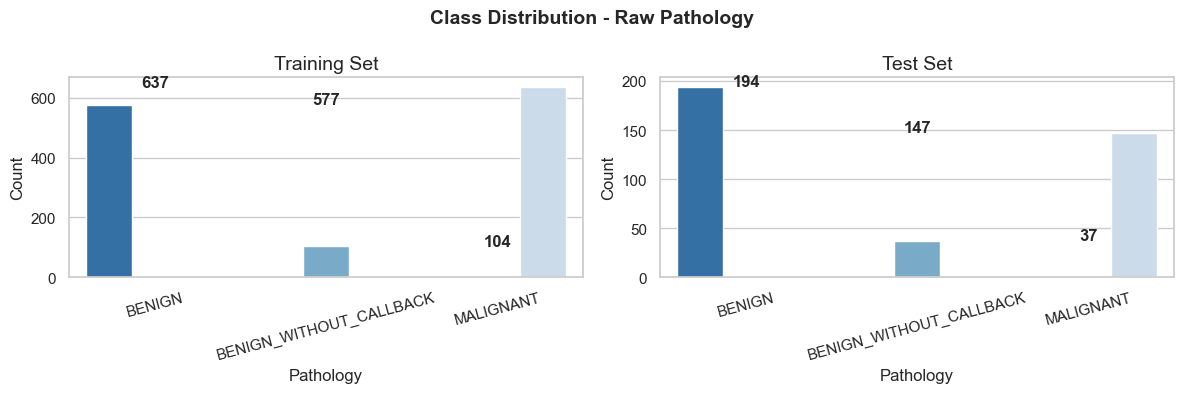

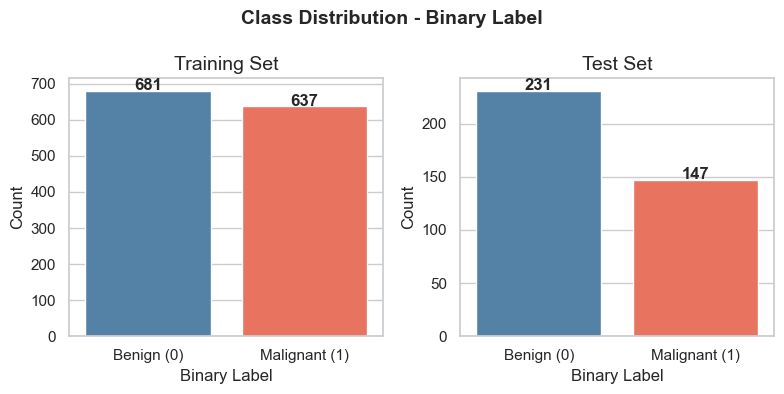


Training label balance:
label
0    0.517
1    0.483
Name: proportion, dtype: float64

Test label balance:
label
0    0.611
1    0.389
Name: proportion, dtype: float64

Patient-level distribution - Train:
  Malignant patients : 346 (50.1%)
  Benign patients    : 345 (49.9%)
  Patient-level ratio: 1.00:1

Patient-level distribution - Test:
  Malignant patients : 85 (42.3%)
  Benign patients    : 116 (57.7%)
  Patient-level ratio: 1.36:1
Class imbalance ratio (benign:malignant): 1.07:1
Naive majority-class accuracy: 51.7%

=== Three-Way Pathology Breakdown (Training Set) ===
  MALIGNANT                    :  637  (48.3%)
  BENIGN                       :  577  (43.8%)
  BENIGN_WITHOUT_CALLBACK      :  104  (7.9%)

BENIGN_WITHOUT_CALLBACK (104 cases) mapped to label 0 (consistent with Lee et al., 2017; Wang, 2024).
CBIS-DDSM malignancy rate (train): 48.3%  (~74x enriched vs real-world screening)


In [8]:
_LABEL_MAP = {"MALIGNANT": 1, "BENIGN": 0, "BENIGN_WITHOUT_CALLBACK": 0}


def map_label(df: pd.DataFrame) -> pd.DataFrame:
    """Add binary 'label' column; BENIGN_WITHOUT_CALLBACK maps to 0 following
    Lee et al. (2017) and Wang (2024)."""
    df = df.copy()
    df["label"] = df["pathology"].map(_LABEL_MAP)
    unexpected = df["label"].isna().sum()
    if unexpected:
        raise ValueError(
            f"{unexpected} rows could not be mapped - unexpected pathology "
            f"values: {df[df['label'].isna()]['pathology'].unique()}"
        )
    df["label"] = df["label"].astype(int)
    return df


train_df = map_label(train_df)
test_df = map_label(test_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, df, title in zip(axes, [train_df, test_df], ["Training Set", "Test Set"]):
    counts = df["pathology"].value_counts()
    sns.barplot(
        x=counts.index,
        y=counts.values,
        hue=counts.index,
        palette="Blues_r",
        legend=False,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Pathology")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=15)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 1, str(v), ha="center", fontweight="bold")

plt.suptitle("Class Distribution - Raw Pathology", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(CONFIG["figures_dir"] / "class_distribution_raw.png")
plt.show()

fig2, axes2 = plt.subplots(1, 2, figsize=(8, 4))
for ax, df, title in zip(axes2, [train_df, test_df], ["Training Set", "Test Set"]):
    counts = df["label"].value_counts().sort_index()
    sns.barplot(
        x=["Benign (0)", "Malignant (1)"],
        y=counts.values,
        hue=["Benign (0)", "Malignant (1)"],
        palette=["steelblue", "tomato"],
        legend=False,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Binary Label")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 1, str(v), ha="center", fontweight="bold")

plt.suptitle("Class Distribution - Binary Label", fontsize=14, fontweight="bold")
plt.tight_layout()
fig2.savefig(CONFIG["figures_dir"] / "class_distribution_binary.png")
plt.show()

print("\nTraining label balance:")
print(train_df["label"].value_counts(normalize=True).round(3))
print("\nTest label balance:")
print(test_df["label"].value_counts(normalize=True).round(3))

# Patient-level distribution; max() labels a patient malignant if any mass is — clinically conservative.
for split_name, df in [("Train", train_df), ("Test", test_df)]:
    patient_labels = df.groupby("patient_id")["label"].max()
    mal = (patient_labels == 1).sum()
    ben = (patient_labels == 0).sum()
    print(f"\nPatient-level distribution - {split_name}:")
    print(f"  Malignant patients : {mal} ({mal/len(patient_labels):.1%})")
    print(f"  Benign patients    : {ben} ({ben/len(patient_labels):.1%})")
    print(f"  Patient-level ratio: {ben/mal:.2f}:1")

majority_class_acc = train_df["label"].value_counts(normalize=True).max()
imbalance_ratio = (train_df["label"] == 0).sum() / (train_df["label"] == 1).sum()
print(f"Class imbalance ratio (benign:malignant): {imbalance_ratio:.2f}:1")
print(f"Naive majority-class accuracy: {majority_class_acc:.1%}")

# BENIGN_WITHOUT_CALLBACK = no recall required; most confidently benign cases.
print("\n=== Three-Way Pathology Breakdown (Training Set) ===")
for cat in ["MALIGNANT", "BENIGN", "BENIGN_WITHOUT_CALLBACK"]:
    n = (train_df["pathology"] == cat).sum()
    pct = n / len(train_df) * 100
    print(f"  {cat:<28} : {n:4d}  ({pct:.1f}%)")

bwc_n = (train_df["pathology"] == "BENIGN_WITHOUT_CALLBACK").sum()
print(f"\nBENIGN_WITHOUT_CALLBACK ({bwc_n} cases) mapped to label 0 (consistent with Lee et al., 2017; Wang, 2024).")

# CBIS-DDSM is ~70x enriched over real-world screening prevalence (~0.65%, NHS England 2022).
_nhs_prev_pct = 0.65
_cbis_mal_pct = (train_df["label"] == 1).mean() * 100
_enrichment = _cbis_mal_pct / _nhs_prev_pct

print(f"CBIS-DDSM malignancy rate (train): {_cbis_mal_pct:.1f}%  (~{_enrichment:.0f}x enriched vs real-world screening)")

## 5. Clinical Feature Distributions

The CBIS-DDSM records radiologist-assigned descriptors for each mass.
Understanding their distributions is important for three reasons:

1. **Mass shape and margins** are the primary radiological features used
   by clinicians to distinguish benign from malignant masses (American
   College of Radiology BI-RADS Atlas, 5th ed.). If the CNN learns
   representations that correlate with these features, this can be verified
   via Grad-CAM visualisations in later notebooks.

2. **Assessment** records the radiologist's BI-RADS score (ACR, 2013):
   categories 1-2 indicate benign findings; category 3 indicates probable
   benignity; categories 4-5 indicate suspicion of malignancy and typically
   prompt biopsy. The distribution of assessment scores across pathology
   classes provides a direct measure of radiologist-model agreement potential.

3. **Subtlety** scores indicate case difficulty. Per Lee et al. (2017),
   subtlety is scored **1 (subtle, hardest to detect) to 5 (obvious, easiest
   to detect)**. A dataset with high proportions of score 1-2 cases is more
   clinically realistic, as these represent subtle abnormalities most likely
   to cause missed diagnoses in screening practice.

Missing values in `mass shape` and `mass margins` (identified in Section 2)
are shown explicitly in the distributions below and do not affect the CNN
pipeline, as model input is the raw image.

Feature                     χ²         p    df       V   Sig  Interpretation
──────────────────────────────────────────────────────────────────────────────


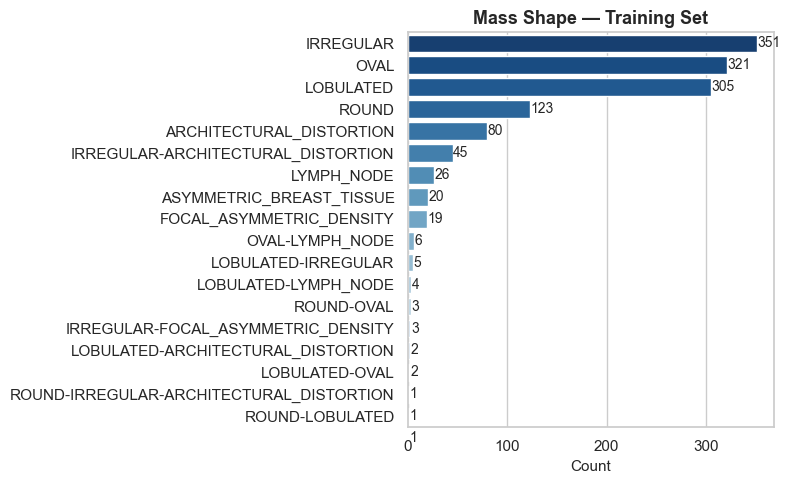

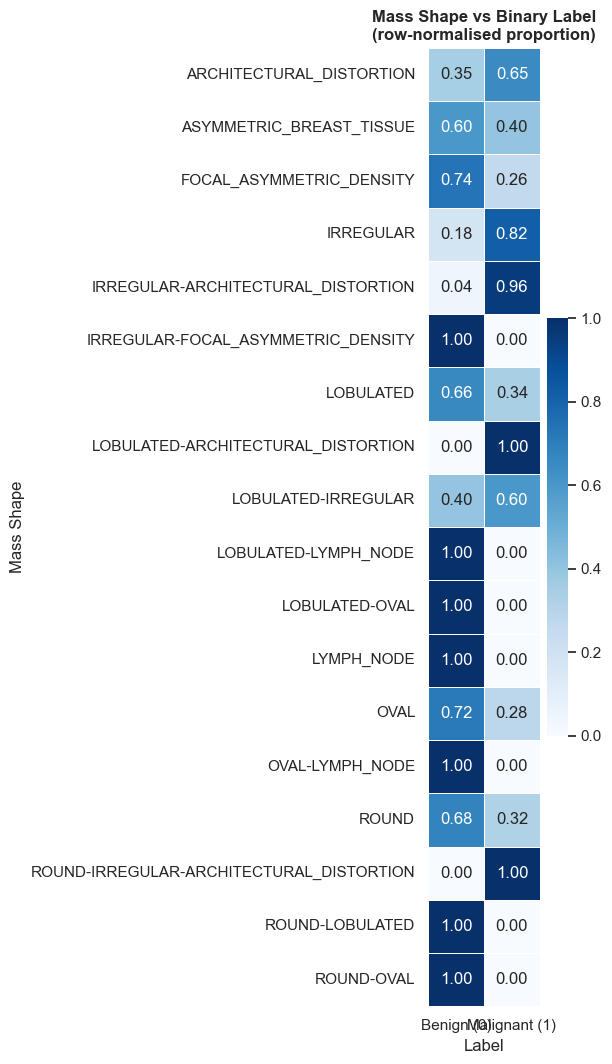

Mass Shape              342.91    0.0000    17   0.511   ***  large effect


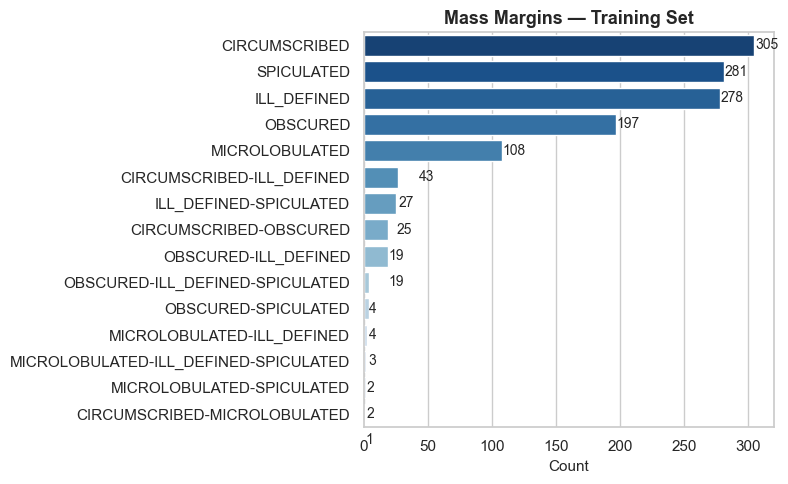

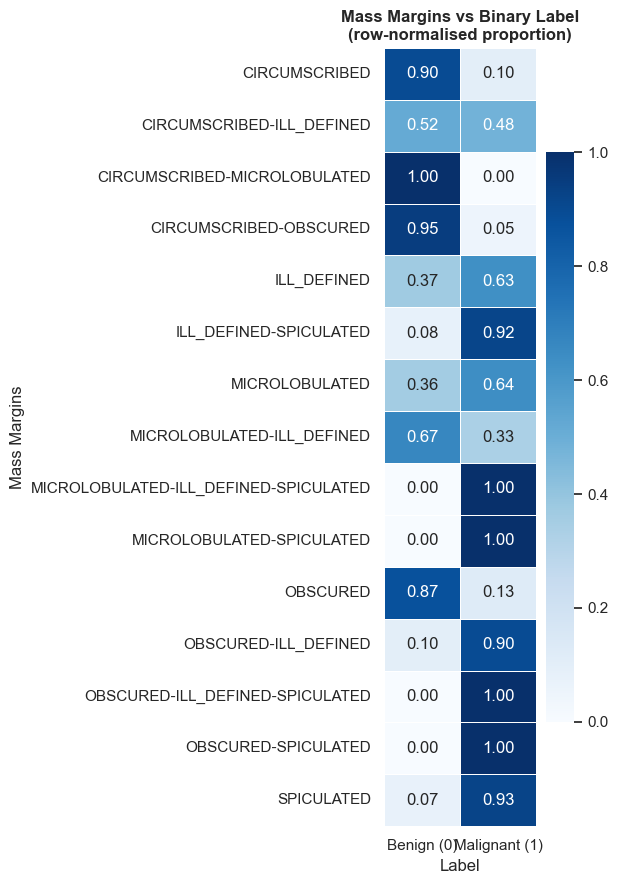

Mass Margins            588.29    0.0000    14   0.679   ***  large effect


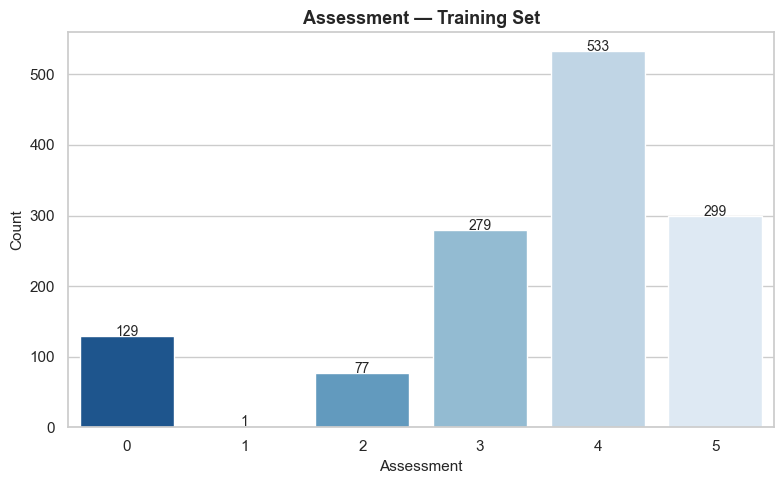

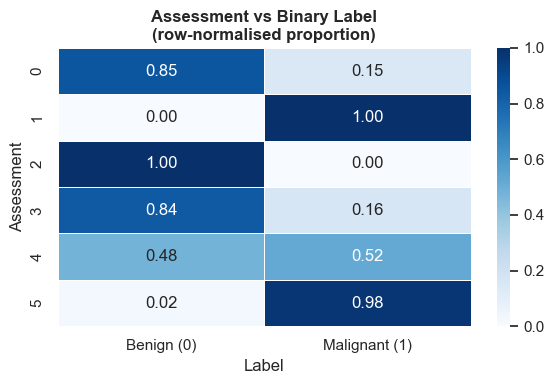

Assessment              546.02    0.0000     5   0.644   ***  large effect


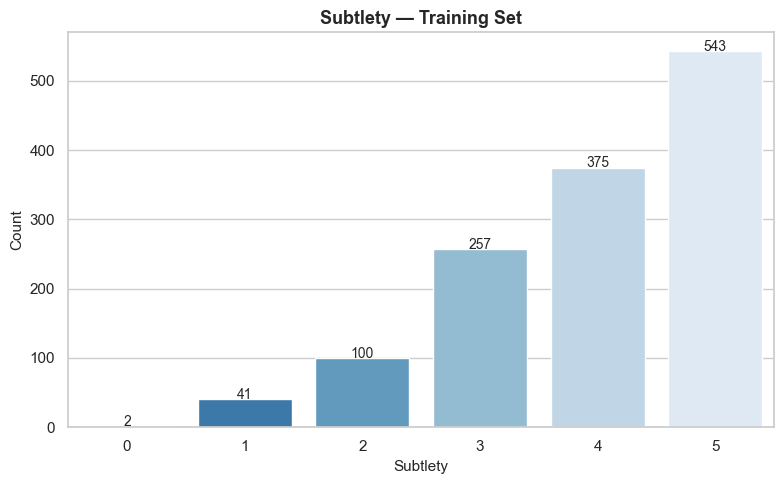

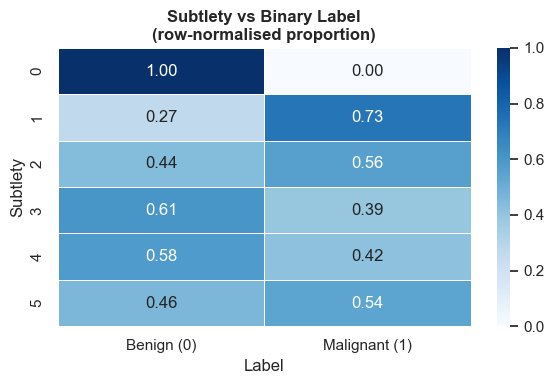

Subtlety                 36.90    0.0000     5   0.167   ***  small effect

Cramér's V: 0.1-0.3 = small, 0.3-0.5 = medium, >0.5 = large effect
Chi-square significance: * p<0.05, ** p<0.01, *** p<0.001

=== Mann-Whitney U Test (ordinal features: assessment, subtlety) ===

Assessment
  U = 366381,  p = 8.1727e-114,  r_rb = -0.689  ***
  Malignant mean: 4.27  |  Benign mean: 2.79
  → Malignant cases score higher on assessment

Subtlety
  U = 229741,  p = 4.9846e-02,  r_rb = -0.059  *
  Malignant mean: 3.99  |  Benign mean: 3.95
  → Malignant cases score higher on subtlety

=== Train vs Test Distribution Comparison (proportions) ===

--- Mass Shape ---
                                          Train   Test
mass shape                                            
ARCHITECTURAL_DISTORTION                  0.061  0.061
ASYMMETRIC_BREAST_TISSUE                  0.015  0.013
FOCAL_ASYMMETRIC_DENSITY                  0.014  0.016
IRREGULAR                                 0.266  0.299
IRREGULAR-ARC

In [9]:
present_cols = [c for c in CONFIG["clinical_cols"] if c in train_df.columns]

print(
    f"{'Feature':<20}  {'χ²':>8}  {'p':>8}  {'df':>4}  {'V':>6}  {'Sig':>4}  Interpretation"
)
print("─" * 78)

for col in present_cols:

    # Distribution plot (training set)
    counts = train_df[col].value_counts(dropna=False)

    fig, ax = plt.subplots(figsize=(8, 5))
    if len(counts) > 6:
        sns.barplot(
            x=counts.values,
            y=counts.index.astype(str),
            hue=counts.index.astype(str),
            palette="Blues_r",
            legend=False,
            ax=ax,
        )
        ax.set_xlabel("Count", fontsize=11)
        ax.set_ylabel("")
        for i, v in enumerate(counts.values):
            ax.text(v + 0.5, i, str(v), va="center", fontsize=10)
    else:
        if col in ("assessment", "subtlety"):
            counts = counts.sort_index()
        sns.barplot(
            x=counts.index.astype(str),
            y=counts.values,
            hue=counts.index.astype(str),
            palette="Blues_r",
            legend=False,
            ax=ax,
        )
        ax.set_xlabel(col.title(), fontsize=11)
        ax.set_ylabel("Count", fontsize=11)
        for i, v in enumerate(counts.values):
            ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)

    ax.set_title(f"{col.title()} — Training Set", fontsize=13, fontweight="bold")
    plt.tight_layout()
    fig.savefig(
        CONFIG["figures_dir"] / f"clinical_{col.replace(' ', '_')}_distribution.png"
    )
    plt.show()

    # Binary label heatmap (row-normalised)
    ct = pd.crosstab(train_df[col], train_df["label"], normalize="index").round(3)
    ct.columns = ["Benign (0)", "Malignant (1)"]

    fig, ax = plt.subplots(figsize=(6, max(4, len(ct) * 0.6)))
    sns.heatmap(
        ct, annot=True, fmt=".2f", cmap="Blues", linewidths=0.5, ax=ax, vmin=0, vmax=1
    )
    ax.set_title(
        f"{col.title()} vs Binary Label\n(row-normalised proportion)",
        fontsize=12,
        fontweight="bold",
    )
    ax.set_xlabel("Label")
    ax.set_ylabel(col.title())
    plt.tight_layout()
    fig.savefig(
        CONFIG["figures_dir"] / f"clinical_{col.replace(' ', '_')}_vs_label.png"
    )
    plt.show()

    # Cramér's V measures association strength — with n=1318, p-values alone are uninformative.
    ct_raw = pd.crosstab(
        train_df[col].dropna(), train_df.loc[train_df[col].notna(), "label"]
    )
    chi2_stat, p_val, dof, _ = chi2_contingency(ct_raw)

    n_ct = ct_raw.values.sum()
    k, r = ct_raw.shape
    v = np.sqrt(chi2_stat / (n_ct * (min(k, r) - 1)))

    sig = (
        "***"
        if p_val < 0.001
        else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else "ns"))
    )
    v_str = "small" if v < 0.3 else ("medium" if v < 0.5 else "large")
    print(
        f"{col.title():<20}  {chi2_stat:>8.2f}  {p_val:>8.4f}  {dof:>4}  {v:>6.3f}  {sig:>4}  {v_str} effect"
    )

print()
print("Cramér's V: 0.1-0.3 = small, 0.3-0.5 = medium, >0.5 = large effect")
print("Chi-square significance: * p<0.05, ** p<0.01, *** p<0.001")
print()

# Mann-Whitney U preserves ordinal structure that chi-square discards.
print("=== Mann-Whitney U Test (ordinal features: assessment, subtlety) ===\n")
for col in ["assessment", "subtlety"]:
    if col not in train_df.columns:
        continue
    g0 = train_df[train_df["label"] == 0][col].dropna()
    g1 = train_df[train_df["label"] == 1][col].dropna()
    stat, p = mannwhitneyu(g1, g0, alternative="two-sided")
    n0, n1 = len(g0), len(g1)
    r_rb = 1 - (2 * stat) / (n0 * n1)
    direction = "higher" if g1.mean() > g0.mean() else "lower"
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    print(f"{col.title()}")
    print(f"  U = {stat:.0f},  p = {p:.4e},  r_rb = {r_rb:+.3f}  {sig}")
    print(f"  Malignant mean: {g1.mean():.2f}  |  Benign mean: {g0.mean():.2f}")
    print(f"  → Malignant cases score {direction} on {col}")
    print()

# Train vs test distribution comparison
print("=== Train vs Test Distribution Comparison (proportions) ===\n")
for col in present_cols:
    train_props = train_df[col].value_counts(normalize=True, dropna=False).round(3)
    test_props = test_df[col].value_counts(normalize=True, dropna=False).round(3)
    comparison = pd.DataFrame({"Train": train_props, "Test": test_props}).fillna(0)
    print(f"--- {col.title()} ---")
    print(comparison.to_string())
    print()

## 5b. Breast Density

ACR BI-RADS breast density is classified on a four-point scale:
- **Category 1** (almost entirely fatty): High contrast; masses visible against fatty background
- **Category 2** (scattered fibroglandular): Some dense areas; most masses visible
- **Category 3** (heterogeneously dense): Moderate masking; some masses may be hidden
- **Category 4** (extremely dense): Severe masking; mammographic sensitivity significantly reduced

Dense breast tissue (categories 3-4) attenuates X-rays in a similar way to soft-tissue
lesions, reducing the contrast that distinguishes masses from background parenchyma.
Mammographic sensitivity falls from ~90% in fatty breasts to ~60-70% in extremely dense
breasts (Kolb et al., 2002). This is the central challenge that motivates AI-assisted
reading: a CNN may detect visual patterns in dense tissue that radiologists miss (McKinney
et al., 2020; Wang, 2024).

**Case-selection enrichment artefact**: In real-world screening populations, breast
density is associated with both higher cancer incidence and lower mammographic
sensitivity. However, CBIS-DDSM is curated from cases that were *already recalled for
assessment* — meaning every patient had a finding suspicious enough to warrant closer
examination. This case-selection process breaks the real-world density→prevalence link:
among recalled patients, malignancy probability depends on the nature of the finding,
not the background tissue density. The near-flat malignancy rate across density
categories seen below (D1≈47%, D2≈49%, D3≈50%, D4≈43%) is therefore expected and does
not contradict the clinical literature — it reflects dataset enrichment, not biology.

**Train vs test density shift**: The test set contains proportionally fewer low-density
cases (D1: 13.2% vs. 21.8% in training) and more dense-tissue cases (D4: 11.6% vs.
8.3%). This covariate shift means density-related performance gaps may be more apparent
at test time than during training. Phase 9 evaluation should stratify metrics by density
category to detect this.

The distribution of density categories and their statistical association with malignancy
probability (after conditioning on recall) are characterised below.

**Phase 9 evaluation note**: sensitivity should be stratified by breast density to test
whether the trained CNN degrades in dense tissue as human readers do.

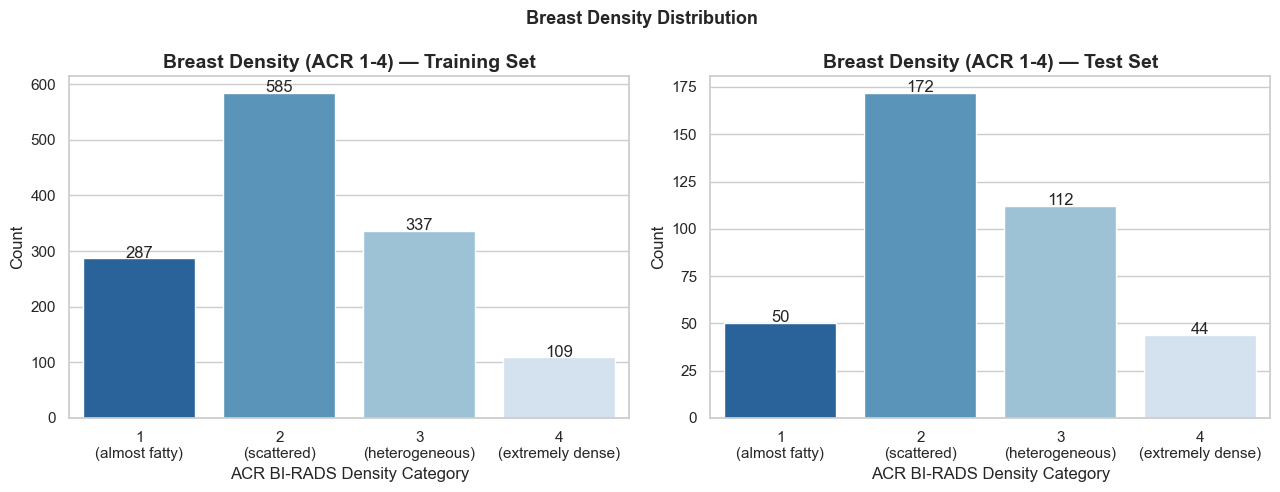

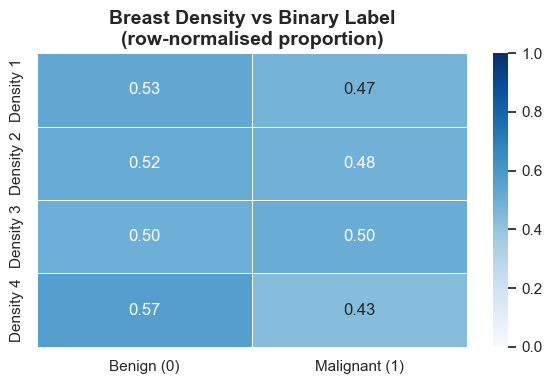

=== Breast Density Association with Malignancy ===

Chi-square  : χ²=1.90,  p=0.5930,  df=3
Cramér's V  : 0.038  (small effect)  ns
Mann-Whitney: U=217479,  p=0.9289,  r_rb=-0.003  ns

Malignancy rate per density category (training set):
  Density 1: 47.4% malignant  (n= 287)  ██████████████
  Density 2: 48.5% malignant  (n= 585)  ██████████████
  Density 3: 50.4% malignant  (n= 337)  ███████████████
  Density 4: 43.1% malignant  (n= 109)  ████████████

=== Breast Density — Train vs Test Comparison ===
                Train   Test
breast_density              
1               0.218  0.132
2               0.444  0.455
3               0.256  0.296
4               0.083  0.116


In [10]:
_density_labels = {
    1: "1\n(almost fatty)",
    2: "2\n(scattered)",
    3: "3\n(heterogeneous)",
    4: "4\n(extremely dense)",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, df, title in zip(axes, [train_df, test_df], ["Training Set", "Test Set"]):
    counts = df["breast_density"].value_counts().sort_index()
    x_labels = [_density_labels.get(int(i), str(i)) for i in counts.index]
    sns.barplot(
        x=x_labels,
        y=counts.values,
        hue=x_labels,
        palette="Blues_r",
        legend=False,
        ax=ax,
    )
    ax.set_title(f"Breast Density (ACR 1-4) — {title}", fontweight="bold")
    ax.set_xlabel("ACR BI-RADS Density Category")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.5, str(v), ha="center")

plt.suptitle("Breast Density Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig(CONFIG["figures_dir"] / "breast_density_distribution.png")
plt.show()

ct_bd = pd.crosstab(
    train_df["breast_density"], train_df["label"], normalize="index"
).round(3)
ct_bd.columns = ["Benign (0)", "Malignant (1)"]
ct_bd.index = [f"Density {int(i)}" for i in ct_bd.index]

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    ct_bd, annot=True, fmt=".2f", cmap="Blues", linewidths=0.5, ax=ax, vmin=0, vmax=1
)
ax.set_title(
    "Breast Density vs Binary Label\n(row-normalised proportion)", fontweight="bold"
)
plt.tight_layout()
fig.savefig(CONFIG["figures_dir"] / "breast_density_vs_label.png")
plt.show()

ct_bd_raw = pd.crosstab(train_df["breast_density"], train_df["label"])
chi2_bd, p_bd, dof_bd, _ = chi2_contingency(ct_bd_raw)
n_bd = ct_bd_raw.values.sum()
k_bd, r_bd = ct_bd_raw.shape
v_bd = np.sqrt(chi2_bd / (n_bd * (min(k_bd, r_bd) - 1)))

print("=== Breast Density Association with Malignancy ===\n")
print(f"Chi-square  : χ²={chi2_bd:.2f},  p={p_bd:.4f},  df={dof_bd}")
sig_bd = (
    "***" if p_bd < 0.001 else ("**" if p_bd < 0.01 else ("*" if p_bd < 0.05 else "ns"))
)
v_bd_str = "small" if v_bd < 0.3 else ("medium" if v_bd < 0.5 else "large")
print(f"Cramér's V  : {v_bd:.3f}  ({v_bd_str} effect)  {sig_bd}")

# Mann-Whitney U (density is ordinal: 1 < 2 < 3 < 4)
g0_bd = train_df[train_df["label"] == 0]["breast_density"]
g1_bd = train_df[train_df["label"] == 1]["breast_density"]
stat_bd, p_mw_bd = mannwhitneyu(g1_bd, g0_bd, alternative="two-sided")
n0_bd, n1_bd = len(g0_bd), len(g1_bd)
r_rb_bd = 1 - (2 * stat_bd) / (n0_bd * n1_bd)
sig_mw_bd = (
    "***"
    if p_mw_bd < 0.001
    else ("**" if p_mw_bd < 0.01 else ("*" if p_mw_bd < 0.05 else "ns"))
)

print(
    f"Mann-Whitney: U={stat_bd:.0f},  p={p_mw_bd:.4f},  r_rb={r_rb_bd:+.3f}  {sig_mw_bd}"
)
print()

print("Malignancy rate per density category (training set):")
_dens_stats = (
    train_df.groupby("breast_density")["label"].agg(["mean", "count"]).reset_index()
)
_dens_stats.columns = ["density", "malignant_rate", "count"]

for _, row in _dens_stats.iterrows():
    bar = "█" * int(row["malignant_rate"] * 30)
    d_lbl = _density_labels.get(int(row["density"]), str(int(row["density"])))
    print(
        f"  Density {int(row['density'])}: {row['malignant_rate']:.1%} malignant  "
        f"(n={int(row['count']):4d})  {bar}"
    )

print("\n=== Breast Density — Train vs Test Comparison ===")
_bd_comp = pd.DataFrame(
    {
        "Train": train_df["breast_density"]
        .value_counts(normalize=True)
        .sort_index()
        .round(3),
        "Test": test_df["breast_density"]
        .value_counts(normalize=True)
        .sort_index()
        .round(3),
    }
)
print(_bd_comp.to_string())

## 5c. BI-RADS Clinical Baseline and Radiologist-Pathology Discordance

Before building any CNN, establishing the performance achievable from clinical features
alone sets the minimum bar the model must exceed to be useful.

**BI-RADS assessment** (`assessment` column, scores 0-5) is the radiologist's summary
judgement. In clinical practice, BI-RADS ≥ 4 triggers biopsy referral (ACR BI-RADS
Atlas, 5th ed., 2013). Applying this same threshold here gives the sensitivity and
specificity that the radiologist's scoring system achieves on this dataset.

Using the BI-RADS score as a *continuous* predictor and computing its AUC-ROC gives
a second, threshold-free baseline. **Any CNN claiming clinical utility must exceed
both**. The binding CNN training targets derived from this dataset are:

> **AUC-ROC > 0.820** — the BI-RADS continuous-score baseline (deduplicated test set, n=361; computed in Cell 20)  
> **AUC-PR > 0.724** — the BI-RADS precision-recall baseline (deduplicated test set, n=361; computed in Cell 20)  
> **Sensitivity > 0.931** — the BI-RADS ≥ 4 threshold baseline (135/145 true cancers detected; deduplicated test set)

A model that does not exceed these values adds no discriminative value beyond the
radiologist's existing BI-RADS assessment.

**BI-RADS 1 scoring anomaly**: One training case has assessment = 1 (definitively
negative — the lowest suspicion score) but pathology = MALIGNANT. BI-RADS 1 in
clinical practice means no abnormality detected; a malignant pathology outcome is
therefore inconsistent with the score. This is almost certainly a data-entry error in
the source CBIS-DDSM CSV and should be treated as a single anomalous record. It is
retained in the analysis for completeness.

**Discordant cases** — where the BI-RADS score and the pathology-confirmed label
disagree — are the most clinically significant cases in the dataset:
- *False alarms* (BI-RADS ≥ 4, pathology BENIGN): unnecessary biopsy referral
- *Missed cancers* (BI-RADS ≤ 2, pathology MALIGNANT): the highest-value cases for AI

If the CNN can correctly classify missed cancers, it adds genuine clinical value beyond
what the radiologist's feature-level assessment captures.

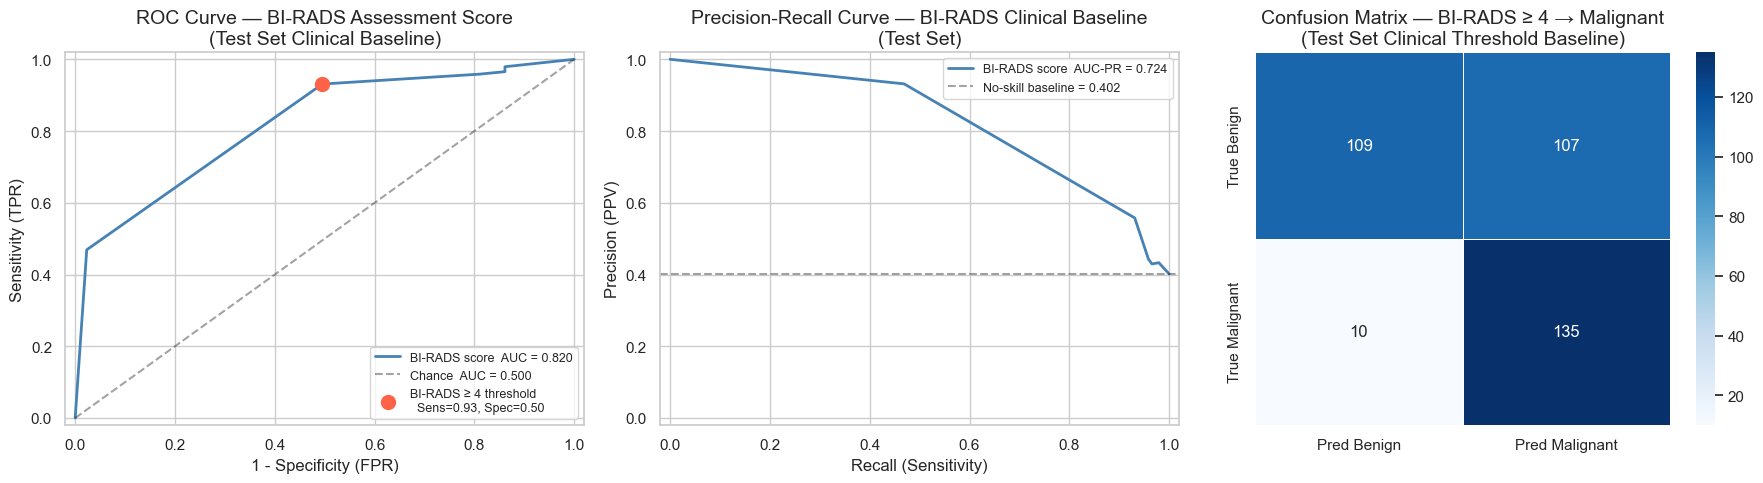

=== BI-RADS Clinical Baseline — TEST SET (BI-RADS ≥ 4 → predict malignant) ===
  Sensitivity (Recall): 0.931  — 135/145 true cancers detected
  Specificity: 0.505  — 109/216 true benigns correctly excluded
  PPV (Precision): 0.558
  NPV: 0.916
  Accuracy: 0.676

=== BI-RADS Score as Continuous Predictor — TEST SET ===
  AUC-ROC (assessment): 0.820
  AUC-PR  (assessment): 0.724

Binding CNN training targets (must exceed on the test set):
  AUC-ROC > 0.820  (exceed BI-RADS discrimination)
  AUC-PR  > 0.724  (exceed BI-RADS precision-recall)
  Sensitivity > 0.931  (exceed BI-RADS threshold recall)

=== Radiologist-Pathology Discordance (Test Set) ===

False alarms  (BI-RADS ≥ 4, pathology BENIGN)     : 107 cases  (29.6%)

Missed cancers (BI-RADS ≤ 2, pathology MALIGNANT) :   6 cases  (1.7%)


,patient_id,assessment,pathology,mass shape,mass margins,subtlety
202,P_00962,0,MALIGNANT,IRREGULAR,OBSCURED,3
203,P_00962,0,MALIGNANT,IRREGULAR,OBSCURED,3
150,P_00641,1,MALIGNANT,IRREGULAR,OBSCURED-ILL_DEFINED,2
151,P_00641,1,MALIGNANT,IRREGULAR,ILL_DEFINED,2
366,P_01800,2,MALIGNANT,IRREGULAR,ILL_DEFINED,2
280,P_01351,0,MALIGNANT,IRREGULAR,OBSCURED,3



Subtlety — missed malignancies  : mean=2.50
Subtlety — detected malignancies: mean=4.02


In [11]:
# Deduplicate to match the 361 unique images the CNN will be evaluated on.
_df_bi = (
    test_df.sort_values("label", ascending=False)
    .drop_duplicates(subset=["image file path"])
    .dropna(subset=["assessment"])
    .copy()
)
_y_true = _df_bi["label"].values
_y_score = _df_bi["assessment"].values  # continuous BI-RADS score (0-5)

_auc_bi = roc_auc_score(_y_true, _y_score)
_fpr, _tpr, _thresholds = roc_curve(_y_true, _y_score)

_auc_pr_bi = average_precision_score(_y_true, _y_score)
_precision, _recall, _ = precision_recall_curve(_y_true, _y_score)

_y_pred = (_y_score >= 4).astype(int)
_cm = confusion_matrix(_y_true, _y_pred)
_tn, _fp, _fn, _tp = _cm.ravel()

_sensitivity = _tp / (_tp + _fn)
_specificity = _tn / (_tn + _fp)
_ppv = _tp / (_tp + _fp) if (_tp + _fp) > 0 else 0.0
_npv = _tn / (_tn + _fn) if (_tn + _fn) > 0 else 0.0
_accuracy = (_tp + _tn) / len(_y_true)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC curve
axes[0].plot(
    _fpr, _tpr, color="steelblue", lw=2, label=f"BI-RADS score  AUC = {_auc_bi:.3f}"
)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Chance  AUC = 0.500")
_op_idx = np.argmin(np.abs(_thresholds - 4))
axes[0].scatter(
    _fpr[_op_idx],
    _tpr[_op_idx],
    color="tomato",
    s=100,
    zorder=5,
    label=f"BI-RADS ≥ 4 threshold\n  Sens={_sensitivity:.2f}, Spec={_specificity:.2f}",
)
axes[0].set_xlabel("1 - Specificity (FPR)")
axes[0].set_ylabel("Sensitivity (TPR)")
axes[0].set_title("ROC Curve — BI-RADS Assessment Score\n(Test Set Clinical Baseline)")
axes[0].legend(loc="lower right", fontsize=9)
axes[0].set_xlim(-0.02, 1.02)
axes[0].set_ylim(-0.02, 1.02)

# PR curve
_no_skill = (_y_true == 1).mean()
axes[1].plot(
    _recall,
    _precision,
    color="steelblue",
    lw=2,
    label=f"BI-RADS score  AUC-PR = {_auc_pr_bi:.3f}",
)
axes[1].axhline(
    _no_skill,
    color="k",
    linestyle="--",
    alpha=0.4,
    label=f"No-skill baseline = {_no_skill:.3f}",
)
axes[1].set_xlabel("Recall (Sensitivity)")
axes[1].set_ylabel("Precision (PPV)")
axes[1].set_title("Precision-Recall Curve — BI-RADS Clinical Baseline\n(Test Set)")
axes[1].legend(fontsize=9)
axes[1].set_xlim(-0.02, 1.02)
axes[1].set_ylim(-0.02, 1.02)

# Confusion matrix
sns.heatmap(
    _cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    xticklabels=["Pred Benign", "Pred Malignant"],
    yticklabels=["True Benign", "True Malignant"],
    ax=axes[2],
)
axes[2].set_title(
    "Confusion Matrix — BI-RADS ≥ 4 → Malignant\n(Test Set Clinical Threshold Baseline)"
)

plt.tight_layout()
fig.savefig(CONFIG["figures_dir"] / "birads_clinical_baseline.png")
plt.show()

print("=== BI-RADS Clinical Baseline — TEST SET (BI-RADS ≥ 4 → predict malignant) ===")
print(
    f"  Sensitivity (Recall): {_sensitivity:.3f}  — {_tp}/{_tp+_fn} true cancers detected"
)
print(
    f"  Specificity: {_specificity:.3f}  — {_tn}/{_tn+_fp} true benigns correctly excluded"
)
print(f"  PPV (Precision): {_ppv:.3f}")
print(f"  NPV: {_npv:.3f}")
print(f"  Accuracy: {_accuracy:.3f}")
print(f"\n=== BI-RADS Score as Continuous Predictor — TEST SET ===")
print(f"  AUC-ROC (assessment): {_auc_bi:.3f}")
print(f"  AUC-PR  (assessment): {_auc_pr_bi:.3f}")
print(f"\nBinding CNN training targets (must exceed on the test set):")
print(f"  AUC-ROC > {_auc_bi:.3f}  (exceed BI-RADS discrimination)")
print(f"  AUC-PR  > {_auc_pr_bi:.3f}  (exceed BI-RADS precision-recall)")
print(f"  Sensitivity > {_sensitivity:.3f}  (exceed BI-RADS threshold recall)")

_false_alarms = _df_bi[(_df_bi["assessment"] >= 4) & (_df_bi["label"] == 0)]
_missed = _df_bi[(_df_bi["assessment"] <= 2) & (_df_bi["label"] == 1)]

print(f"\n=== Radiologist-Pathology Discordance (Test Set) ===")
print(
    f"\nFalse alarms  (BI-RADS ≥ 4, pathology BENIGN)     : "
    f"{len(_false_alarms):3d} cases  ({len(_false_alarms)/len(_df_bi):.1%})"
)
print(
    f"\nMissed cancers (BI-RADS ≤ 2, pathology MALIGNANT) : "
    f"{len(_missed):3d} cases  ({len(_missed)/len(_df_bi):.1%})"
)

if not _missed.empty:
    _cols_show = [
        c
        for c in [
            "patient_id",
            "assessment",
            "pathology",
            "mass shape",
            "mass margins",
            "subtlety",
        ]
        if c in _missed.columns
    ]
    display(_missed[_cols_show].head(10))

_detected_mal = _df_bi[(_df_bi["assessment"] >= 4) & (_df_bi["label"] == 1)]
if "subtlety" in _df_bi.columns and not _missed.empty:
    print(f"\nSubtlety — missed malignancies  : mean={_missed['subtlety'].mean():.2f}")
    print(
        f"Subtlety — detected malignancies: mean={_detected_mal['subtlety'].mean():.2f}"
    )

## 6. View Coverage - CC and MLO Availability per Patient

In standard mammography protocol, each breast is imaged in both the
craniocaudal (CC) and mediolateral oblique (MLO) projections. Patients
for whom only one view is available have reduced diagnostic coverage and
may be harder cases for both radiologists and CNNs. Documenting view
availability informs whether single-view or multi-view strategies are
feasible for this dataset (Wang, 2024).

**View coverage finding**: Only **~70.5% of patient-breast units** in the
training set (509 / 722) have both CC and MLO images recorded in the CSV;
a further 64 have CC only and 149 have MLO only. The test set is similar
at 71.9% (151 / 210). This means the Phase 7 dual-stream CC+MLO
architecture (Shen et al., 2019) applies to the paired subset only.
The remaining ~29.5% of cases with a single recorded view require either
a separate single-view branch or exclusion from the dual-stream model.
This is a significant dataset constraint that must be acknowledged in the
final report.


=== Training Set ===
Both CC and MLO: 509
CC only: 64
MLO only: 149
Total patient-breast units: 722
Total patients: 691

=== Test Set ===
Both CC and MLO: 151
CC only: 19
MLO only: 40
Total patient-breast units: 210
Total patients: 201


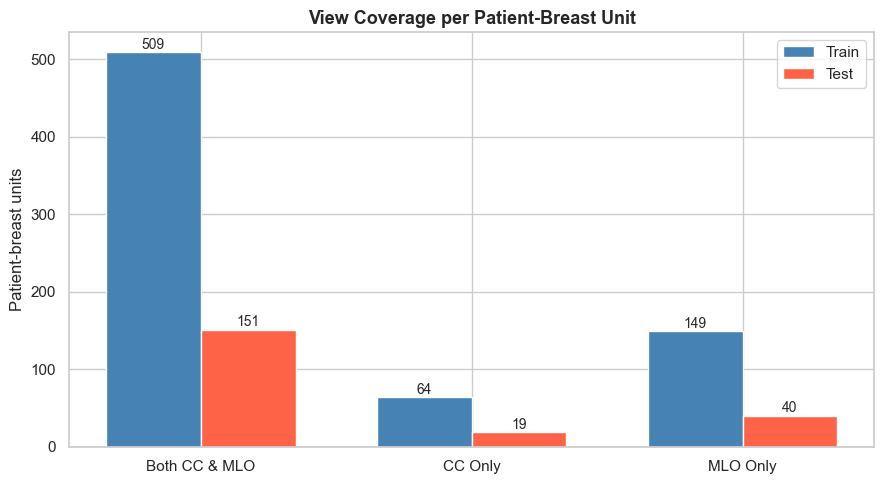


=== Multi-View Pairing — Training Set ===
Patient-breast units total: 722
Complete CC+MLO pairs: 509  (70.5%)
Unpaired (missing CC or MLO): 213
Label distribution (pairs): malignant=252, benign=257  (49.5% malignant)

=== Multi-View Pairing — Test Set ===
Patient-breast units total: 210
Complete CC+MLO pairs: 151  (71.9%)
Unpaired (missing CC or MLO): 59
Label distribution (pairs): malignant=61, benign=90  (40.4% malignant)

Paired DataFrame columns: ['patient_id', 'breast', 'CC', 'MLO', 'label']

Sample (first 3 rows):


,patient_id,breast,CC,MLO,label
0,P_00001,LEFT,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,1
1,P_00004,LEFT,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,0
3,P_00009,RIGHT,Mass-Training_P_00009_RIGHT_CC/1.3.6.1.4.1.959...,Mass-Training_P_00009_RIGHT_MLO/1.3.6.1.4.1.95...,1


In [12]:
def view_coverage(df: pd.DataFrame, name: str) -> dict:
    """Summarise CC/MLO view availability per patient-breast unit.
    
    Measures views with recorded mass annotations, not views taken — a patient
    with a mass visible on CC only will appear CC-only even if MLO exists.
    """
    valid_views = set(CONFIG["valid_views"])
    unexpected = set(df["image view"].dropna().astype(str)) - valid_views
    if unexpected:
        print(f"WARNING [{name}]: unexpected view values: {unexpected}")

    views = df.groupby(["patient_id", "left or right breast"])["image view"].agg(
        frozenset
    )

    both = views.apply(lambda x: "CC" in x and "MLO" in x).sum()
    cc_only = views.apply(lambda x: "CC" in x and "MLO" not in x).sum()
    mlo_only = views.apply(lambda x: "MLO" in x and "CC" not in x).sum()

    print(f"\n=== {name} ===")
    print(f"Both CC and MLO: {both}")
    print(f"CC only: {cc_only}")
    print(f"MLO only: {mlo_only}")
    print(f"Total patient-breast units: {len(views)}")
    print(f"Total patients: {df['patient_id'].dropna().nunique()}")

    return {
        "both": both,
        "cc_only": cc_only,
        "mlo_only": mlo_only,
        "total_units": len(views),
    }


train_coverage = view_coverage(train_df, "Training Set")
test_coverage = view_coverage(test_df, "Test Set")

labels = ["Both CC & MLO", "CC Only", "MLO Only"]
x = np.arange(len(labels))
width = 0.35
train_vals = [
    train_coverage["both"],
    train_coverage["cc_only"],
    train_coverage["mlo_only"],
]
test_vals = [test_coverage["both"], test_coverage["cc_only"], test_coverage["mlo_only"]]

fig, ax = plt.subplots(figsize=(9, 5))
bars_train = ax.bar(x - width / 2, train_vals, width, label="Train", color="steelblue")
bars_test = ax.bar(x + width / 2, test_vals, width, label="Test", color="tomato")

ax.set_title("View Coverage per Patient-Breast Unit", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Patient-breast units")
ax.legend()

for bar in list(bars_train) + list(bars_test):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        str(int(bar.get_height())),
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
fig.savefig(CONFIG["figures_dir"] / "view_coverage.png")
plt.show()

def build_view_pairs(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Pivot to one row per patient-breast unit with CC and MLO path columns.
    Only complete pairs are returned; label = max across the unit (malignant wins).
    """
    df = df.copy()
    df["image view"] = df["image view"].astype(str)

    # Aggregate: one representative image path per (patient, breast, view)
    # First deduplicate within view to handle multi-abnormality images
    agg = (
        df.groupby(["patient_id", "left or right breast", "image view"])
        .agg(img_path=("image file path", "first"), label=("label", "max"))
        .reset_index()
    )

    # Pivot views to columns
    pivot = agg.pivot_table(
        index=["patient_id", "left or right breast"],
        columns="image view",
        values="img_path",
        aggfunc="first",
    ).reset_index()
    pivot.columns.name = None

    # Add patient-breast label (malignant if any view is malignant)
    label_agg = (
        df.groupby(["patient_id", "left or right breast"])["label"].max().reset_index()
    )
    pivot = pivot.merge(
        label_agg, on=["patient_id", "left or right breast"], how="left"
    )

    # Keep only complete CC+MLO pairs
    has_cc = "CC" in pivot.columns
    has_mlo = "MLO" in pivot.columns
    if not (has_cc and has_mlo):
        print(f"WARNING [{name}]: CC or MLO column missing — check view values")
        return pivot

    paired = pivot.dropna(subset=["CC", "MLO"]).copy()
    paired = paired.rename(columns={"left or right breast": "breast"})

    n_total = len(pivot)
    n_paired = len(paired)
    print(f"\n=== Multi-View Pairing — {name} ===")
    print(f"Patient-breast units total: {n_total}")
    print(f"Complete CC+MLO pairs: {n_paired}  ({n_paired/n_total:.1%})")
    print(f"Unpaired (missing CC or MLO): {n_total - n_paired}")
    if "label" in paired.columns:
        mal = paired["label"].sum()
        ben = (paired["label"] == 0).sum()
        print(
            f"Label distribution (pairs): malignant={mal}, benign={ben}  "
            f"({mal/n_paired:.1%} malignant)"
        )

    return paired


train_pairs = build_view_pairs(train_df, "Training Set")
test_pairs = build_view_pairs(test_df, "Test Set")

print("\nPaired DataFrame columns:", train_pairs.columns.tolist())
print(f"\nSample (first 3 rows):")
display(train_pairs[["patient_id", "breast", "CC", "MLO", "label"]].head(3))

## 7. Sample Images by Pathology Class

Visual inspection with pathology labels confirms that the DICOM files are
loading correctly and gives an intuition for the visual differences between
classes that the CNN will need to learn.

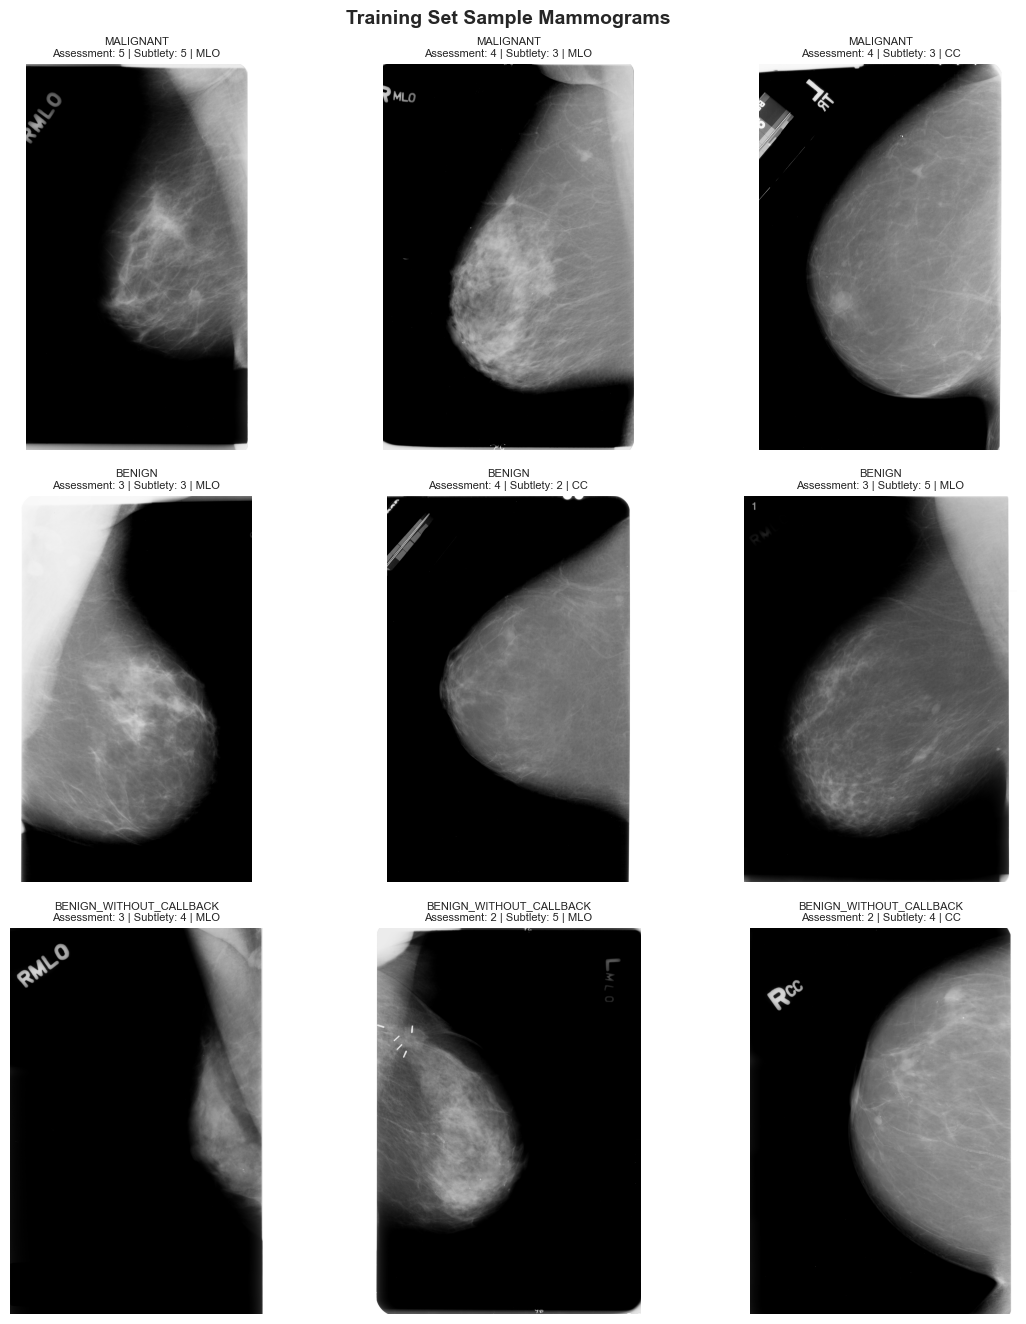

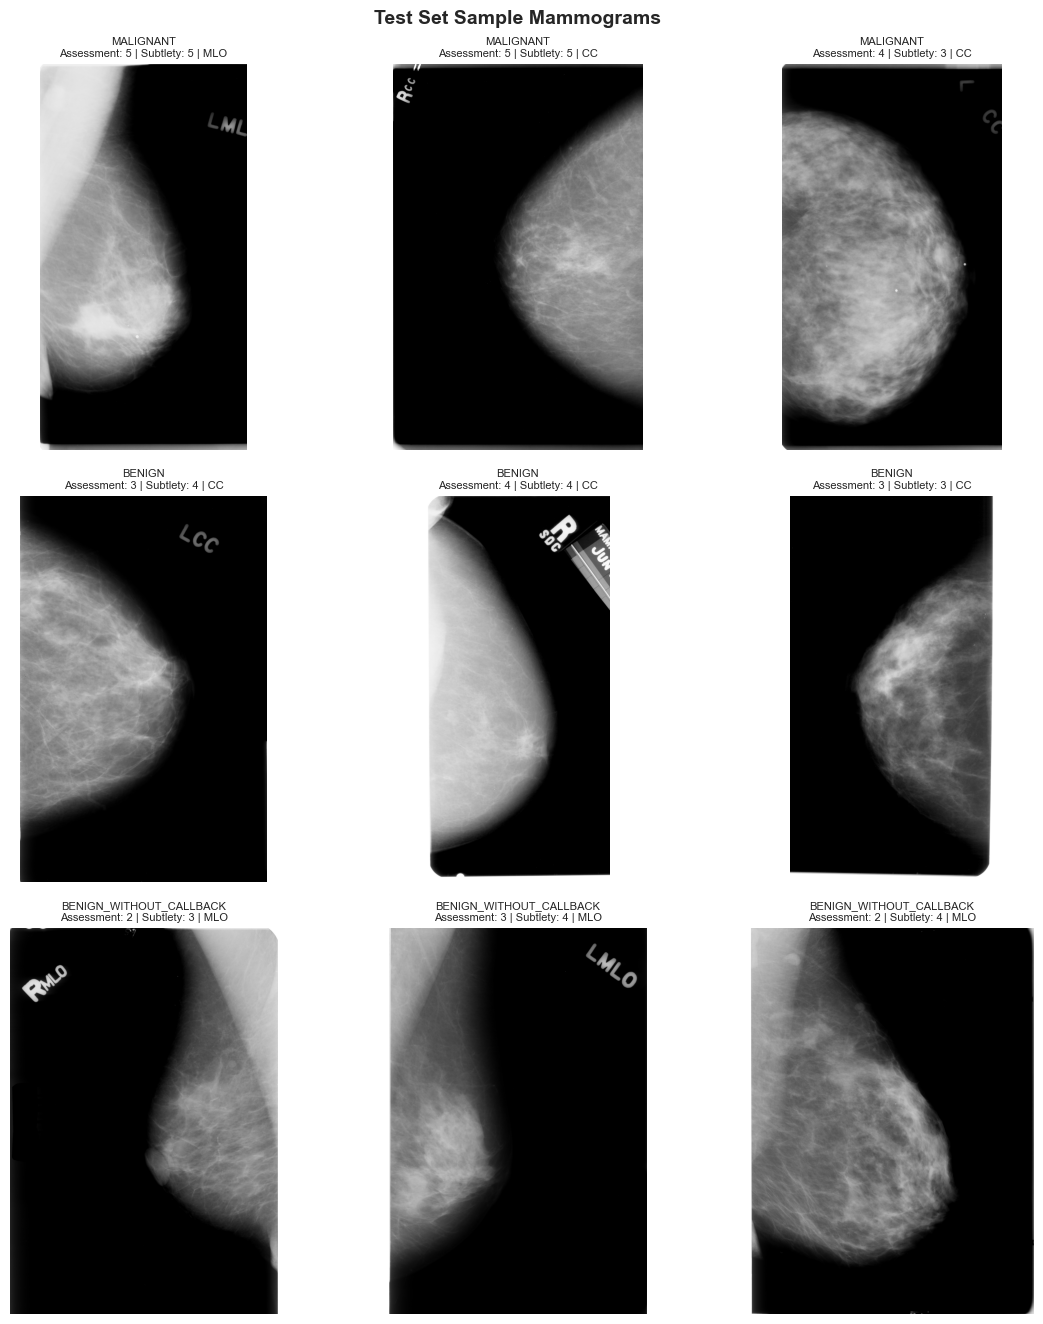

In [13]:
def load_dicom_image(img_dir: Path, csv_path_str: str) -> np.ndarray | None:
    """Load a CBIS-DDSM DICOM by matching parent directory — CSV uses 000000.dcm
    filenames but TCIA downloads use UUIDs. Returns float32 [0,1] or None."""
    candidate_dir = img_dir / Path(csv_path_str).parent
    if not candidate_dir.exists():
        return None

    dcm_files = list(candidate_dir.glob("*.dcm"))
    if not dcm_files:
        return None

    try:
        ds = pydicom.dcmread(dcm_files[0], force=True)
        arr = ds.pixel_array.astype(np.float32)
    except Exception:
        return None

    # Invert MONOCHROME1 so high values always map to bright tissue
    if getattr(ds, "PhotometricInterpretation", "MONOCHROME2") == "MONOCHROME1":
        arr = arr.max() - arr

    # Min-max normalisation for display only — pipeline uses global /65,535.

    if arr.max() > arr.min():
        arr = (arr - arr.min()) / (arr.max() - arr.min())

    return arr


def show_sample_grid(
    df: pd.DataFrame,
    img_dir: Path,
    n_per_class: int = 3,
    title: str = "Sample Mammograms",
    seed: int = CONFIG["seed"],
) -> None:
    """Display a grid of sample mammograms grouped by pathology class.
    Deduplicates on image path before sampling so each column shows a distinct DICOM.
    """
    classes = [
        c
        for c in ["MALIGNANT", "BENIGN", "BENIGN_WITHOUT_CALLBACK"]
        if c in df["pathology"].unique()
    ]

    fig, axes = plt.subplots(
        len(classes),
        n_per_class,
        figsize=(4 * n_per_class, 4.5 * len(classes)),
        squeeze=False,
    )

    for row_idx, cls in enumerate(classes):
        # Deduplicate on image path - one row per DICOM - then sample
        class_df = df[df["pathology"] == cls].drop_duplicates(subset=CONFIG["img_col"])
        subset = class_df.sample(
            n=min(n_per_class, len(class_df)),
            random_state=seed,
        )

        for col_idx, (_, row) in enumerate(subset.iterrows()):
            ax = axes[row_idx][col_idx]
            arr = load_dicom_image(img_dir, row[CONFIG["img_col"]])

            if arr is not None:
                ax.imshow(arr, cmap="gray")
            else:
                ax.text(
                    0.5,
                    0.5,
                    "Image\nnot found",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )

            ax.set_title(
                f"{cls}\n"
                f"Assessment: {row.get('assessment', 'N/A')} | "
                f"Subtlety: {row.get('subtlety', 'N/A')} | "
                f"{row.get('image view', '')}",
                fontsize=8,
            )
            ax.axis("off")

    plt.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    fig.savefig(CONFIG["figures_dir"] / f"{title.replace(' ', '_').lower()}.png")
    plt.show()


show_sample_grid(
    train_df,
    CONFIG["train_img_dir"],
    n_per_class=3,
    title="Training Set Sample Mammograms",
)
show_sample_grid(
    test_df, CONFIG["test_img_dir"], n_per_class=3, title="Test Set Sample Mammograms"
)

## 8. DICOM Metadata Audit

Two DICOM attributes must be checked before any preprocessing is designed:

**`PhotometricInterpretation`**: Mammograms can be stored as either `MONOCHROME1`
(high pixel value = dark; background is bright) or `MONOCHROME2`
(high pixel value = bright; background is dark). If both are present in the
dataset without correction, the model trains on contradictory representations
of tissue density. `MONOCHROME1` images must be inverted before use.

**`BitsStored`**: CBIS-DDSM images can vary between 12-bit and 16-bit depending
on the originating scanner. The audit below confirms the bit depth present in
this copy of the dataset, which determines the correct normalisation denominator
(4,095 for 12-bit; 65,535 for 16-bit).

Both must be documented here and handled explicitly in `data_loader.py`.

Auditing 1231 train DICOMs...
Auditing 361 test DICOMs...

=== TRAIN SET (1231 images) ===

PhotometricInterpretation:
PhotometricInterpretation
MONOCHROME2    1231

BitsStored:
BitsStored
16    1231

BitsAllocated:
BitsAllocated
16    1231

✓  All images MONOCHROME2 — no inversion required
✓  Uniform bit depth: 16-bit

PixelSpacing tag absent from all audited images


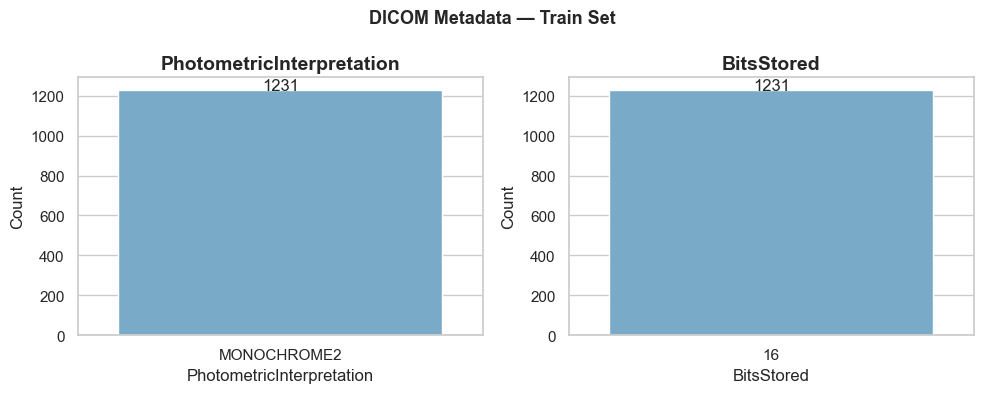


=== TEST SET (361 images) ===

PhotometricInterpretation:
PhotometricInterpretation
MONOCHROME2    361

BitsStored:
BitsStored
16    361

BitsAllocated:
BitsAllocated
16    361

✓  All images MONOCHROME2 — no inversion required
✓  Uniform bit depth: 16-bit

PixelSpacing tag absent from all audited images


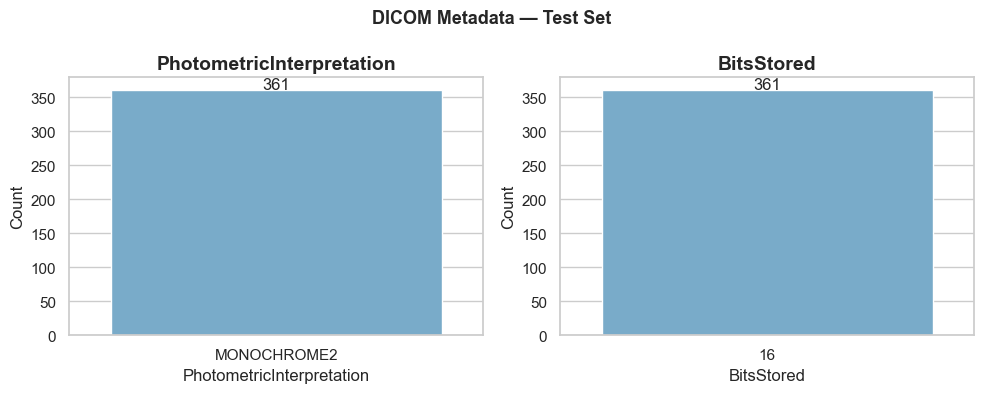

In [14]:
# Full audit using stop_before_pixels — MONOCHROME1 detection is safety-critical.

results = {"train": [], "test": []}

for split_name, img_dir in [
    ("train", CONFIG["train_img_dir"]),
    ("test", CONFIG["test_img_dir"]),
]:
    paths = list(img_dir.glob("**/*.dcm"))
    print(f"Auditing {len(paths)} {split_name} DICOMs...")

    for p in paths:
        try:
            ds = pydicom.dcmread(p, stop_before_pixels=True)
        except Exception as e:
            print(f"  WARNING: could not read {p.name}: {e}")
            continue

        results[split_name].append(
            {
                "path": str(p),
                "PhotometricInterpretation": getattr(
                    ds, "PhotometricInterpretation", "UNKNOWN"
                ),
                "BitsStored": getattr(ds, "BitsStored", "UNKNOWN"),
                "BitsAllocated": getattr(ds, "BitsAllocated", "UNKNOWN"),
                "PixelSpacingRow": (
                    float(ds.PixelSpacing[0]) if hasattr(ds, "PixelSpacing") else None
                ),
                "PixelSpacingCol": (
                    float(ds.PixelSpacing[1]) if hasattr(ds, "PixelSpacing") else None
                ),
                "Rows": int(ds.Rows) if hasattr(ds, "Rows") else None,
                "Columns": int(ds.Columns) if hasattr(ds, "Columns") else None,
            }
        )


for split_name, rows in results.items():
    meta_df = pd.DataFrame(rows)
    print(f"\n=== {split_name.upper()} SET ({len(meta_df)} images) ===")

    print("\nPhotometricInterpretation:")
    print(meta_df["PhotometricInterpretation"].value_counts().to_string())

    print("\nBitsStored:")
    print(meta_df["BitsStored"].value_counts().to_string())

    print("\nBitsAllocated:")
    print(meta_df["BitsAllocated"].value_counts().to_string())

    mono1 = (meta_df["PhotometricInterpretation"] == "MONOCHROME1").sum()
    if mono1 > 0:
        print(f"\n⚠  {mono1} MONOCHROME1 images — inversion required in data_loader.py")
    else:
        print("\n✓  All images MONOCHROME2 — no inversion required")

    if meta_df["BitsStored"].nunique() > 1:
        print(f"⚠  Mixed bit depths: {meta_df['BitsStored'].value_counts().to_dict()}")
    else:
        print(f"✓  Uniform bit depth: {meta_df['BitsStored'].iloc[0]}-bit")

    ps = meta_df[["PixelSpacingRow", "PixelSpacingCol"]].dropna()
    if not ps.empty:
        for dim in ["Row", "Col"]:
            col = f"PixelSpacing{dim}"
            print(
                f"\nPixelSpacing {dim} (mm)  "
                f"mean={ps[col].mean():.4f}  "
                f"std={ps[col].std():.4f}  "
                f"min={ps[col].min():.4f}  "
                f"max={ps[col].max():.4f}"
            )
    else:
        print("\nPixelSpacing tag absent from all audited images")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, col in zip(axes, ["PhotometricInterpretation", "BitsStored"]):
        counts = meta_df[col].value_counts()
        sns.barplot(
            x=counts.index.astype(str),
            y=counts.values,
            hue=counts.index.astype(str),
            palette="Blues_r",
            legend=False,
            ax=ax,
        )
        ax.set_title(col, fontweight="bold")
        ax.set_ylabel("Count")
        for i, v in enumerate(counts.values):
            ax.text(i, v + 0.5, str(v), ha="center")
    plt.suptitle(
        f"DICOM Metadata — {split_name.title()} Set", fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    fig.savefig(CONFIG["figures_dir"] / f"dicom_metadata_{split_name}.png")
    plt.show()

## 9. Image Resolution Distribution

CBIS-DDSM mammograms vary substantially in resolution. The distribution here
directly informs the resizing strategy in `data_loader.py` and must be reported
when justifying the chosen input dimensions to the model.

A common choice in the literature is 224x224 (matching ImageNet input for
transfer learning) or 299x299 (InceptionV3). The chosen size should be justified
against the median native resolution — aggressive downsampling risks discarding
diagnostically relevant fine detail such as microcalcifications
(Wang, 2024; Chollet, 2018, Ch. 5).

**Resolution bimodality**: The height distribution shows two distinct clusters,
consistent with images acquired from two different scanner types or acquisition
protocols across the multiple institutions that contributed to CBIS-DDSM. Different
scanners may have different pixel pitch and noise characteristics; the robust
augmentation strategy (rotation, brightness variation) partially compensates for
this acquisition heterogeneity.

**PixelSpacing tag absent**: The `PixelSpacing` DICOM attribute (physical resolution
in mm/pixel) is absent from these images, so lesion size cannot be derived in
physical units from DICOM metadata alone. This does not affect the pixel-level
classification task but precludes spatial-scale-based feature engineering.

Full audit: 1231 / 1231 training images with resolution data


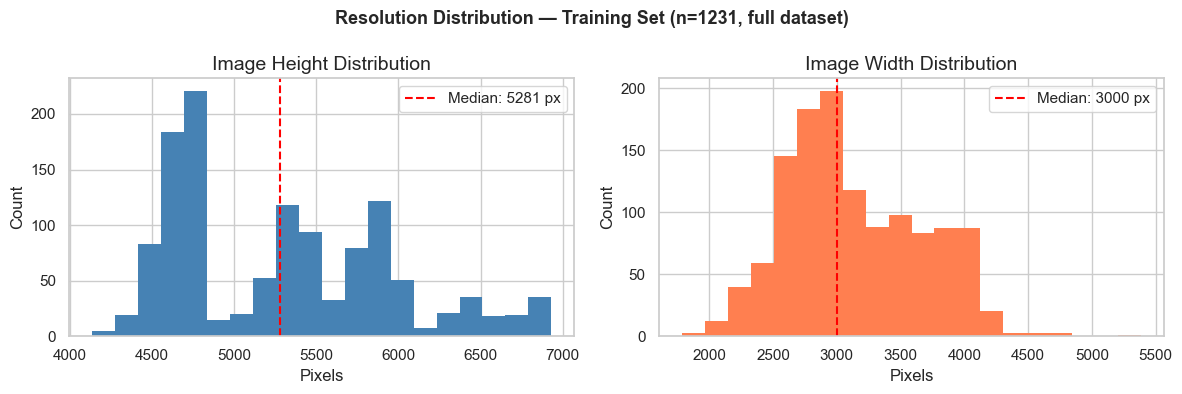

Height — median: 5281 px  |  range: 4136-6931 px
Width  — median: 3000 px  |  range: 1786-5386 px

Downsampling to 224x224:
  Height factor: 23.6x
  Width  factor: 13.4x


In [15]:
# Reuse audit results — no re-reading needed.
_train_meta_full = pd.DataFrame(results["train"])
heights = _train_meta_full["Rows"].dropna().astype(int).tolist()
widths = _train_meta_full["Columns"].dropna().astype(int).tolist()
print(
    f"Full audit: {len(heights)} / {len(_train_meta_full)} training images with resolution data"
)

med_h = np.median(heights)
med_w = np.median(widths)
target_h, target_w = CONFIG["target_size"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, vals, label, colour in [
    (axes[0], heights, "Height", "steelblue"),
    (axes[1], widths, "Width", "coral"),
]:
    med = np.median(vals)
    ax.hist(vals, bins=20, color=colour, edgecolor="none")
    ax.axvline(med, color="red", linestyle="--", label=f"Median: {med:.0f} px")
    ax.set_title(f"Image {label} Distribution")
    ax.set_xlabel("Pixels")
    ax.set_ylabel("Count")
    ax.legend()

plt.suptitle(
    f"Resolution Distribution — Training Set (n={len(heights)}, full dataset)",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
fig.savefig(CONFIG["figures_dir"] / "resolution_distribution.png")
plt.show()

print(f"Height — median: {med_h:.0f} px  |  range: {min(heights)}-{max(heights)} px")
print(f"Width  — median: {med_w:.0f} px  |  range: {min(widths)}-{max(widths)} px")
print(f"\nDownsampling to {target_h}x{target_w}:")
print(f"  Height factor: {med_h/target_h:.1f}x")
print(f"  Width  factor: {med_w/target_w:.1f}x")

if "results" in dir() and results["train"]:
    train_meta = pd.DataFrame(results["train"])
    ps = train_meta[["PixelSpacingRow", "PixelSpacingCol"]].dropna()
    if not ps.empty:
        mean_row_mm = ps["PixelSpacingRow"].mean()
        mean_col_mm = ps["PixelSpacingCol"].mean()
        print(
            f"\nAt {target_h}x{target_w} input, each pixel represents approx. "
            f"{mean_row_mm * (med_h / target_h):.2f} x "
            f"{mean_col_mm * (med_w / target_w):.2f} mm of tissue"
        )

train_meta_df = pd.DataFrame(results["train"])
mono1_count = (train_meta_df["PhotometricInterpretation"] == "MONOCHROME1").sum()
n_audited_train = len(train_meta_df)
bits_stored_dict = train_meta_df["BitsStored"].value_counts().to_dict()

## 9b. Bimodal Resolution — Scanner-Type Confound Check

Section 9 noted a bimodal height distribution suggesting two scanner types. If scanner type (proxied by height > median) correlates with pathology, it is a confound: the model could learn scanner identity rather than pathology.

In [16]:
_img_dir = CONFIG["train_img_dir"]

# Use full audit results — path, Rows, Columns per DICOM.
_scanner_heights, _scanner_labels = [], []
for _row in _train_meta_full.itertuples():
    if pd.isna(_row.Rows):
        continue
    _p = Path(_row.path)
    try:
        top_folder = _p.parent.relative_to(_img_dir).parts[0]
    except (ValueError, IndexError):
        continue
    _csv_rows = train_df[train_df[CONFIG["img_col"]].str.startswith(top_folder)]
    if _csv_rows.empty or "label" not in _csv_rows.columns:
        continue
    _scanner_heights.append(int(_row.Rows))
    _scanner_labels.append(int(_csv_rows["label"].max()))

_scanner_heights = np.array(_scanner_heights)
_scanner_labels = np.array(_scanner_labels)
_scanner_proxy = (_scanner_heights > np.median(heights)).astype(int)

print(
    f"Matched {len(_scanner_heights)} / {len(_train_meta_full)} training images to CSV labels"
)

_ct = pd.crosstab(_scanner_proxy, _scanner_labels)
_ct = _ct.rename(
    index={0: "Height ≤ median", 1: "Height > median"},
    columns={0: "Benign", 1: "Malignant"},
)

_chi2, _p, _dof, _ = chi2_contingency(_ct)
_n = _ct.values.sum()
_v = np.sqrt(_chi2 / (_n * (min(_ct.shape) - 1)))
_sig = "***" if _p < 0.001 else ("**" if _p < 0.01 else ("*" if _p < 0.05 else "ns"))

print()
print(_ct.to_string())
print(f"\nChi-square: χ²={_chi2:.2f},  p={_p:.4f},  df={_dof},  V={_v:.3f}  {_sig}")

if _p < 0.05:
    print("\n⚠  Scanner proxy significantly associated with pathology.")
else:
    print("\n✓  No significant association between scanner proxy and pathology.")

Matched 1231 / 1231 training images to CSV labels

col_0            Benign  Malignant
row_0                             
Height ≤ median     310        312
Height > median     319        290

Chi-square: χ²=0.70,  p=0.4038,  df=1,  V=0.024  ns

✓  No significant association between scanner proxy and pathology.


## 10. Pixel Intensity Distribution

Pixel statistics are computed from **all 1,231 training images** (streaming, one
image at a time) to provide exact rather than approximate training-set constants,
and to confirm the dataset is not trivially separable by global pixel brightness.

**Pixel intensity histogram**: A single-image histogram (below) reveals a
characteristic bimodal structure: a large spike near zero (background air pixels)
and a broad hump in the ~25,000-45,000 range (breast tissue). Two implications:

1. Tissue pixels do not use the full 16-bit range — the /65,535 global normalisation
   is slightly conservative but consistent and bias-free across all images.
2. Per-image min-max normalisation would collapse the background spike to exactly 0
   and the brightest tissue pixel to exactly 1 — erasing inter-image brightness
   differences. The global /65,535 scheme preserves these differences.

**Per-class mean intensity**: If malignant and benign images differed substantially
in mean brightness, the task would be trivially solved by a single threshold on
global intensity. The class-stratified histogram tests this.

Streaming 1231 training DICOMs with 12 threads (M-series NVMe + parallel C-extension decompression)...
  200/1231 processed  (16%)
  400/1231 processed  (32%)
  600/1231 processed  (48%)
  800/1231 processed  (64%)
  1000/1231 processed  (81%)
  1200/1231 processed  (97%)
  1231/1231 processed  (100%)


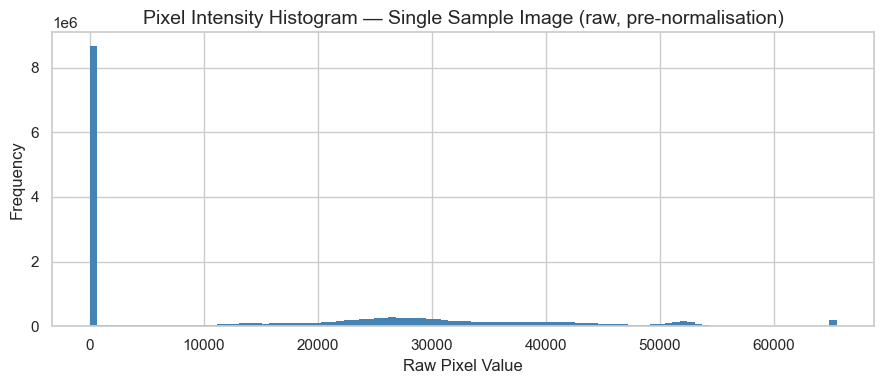

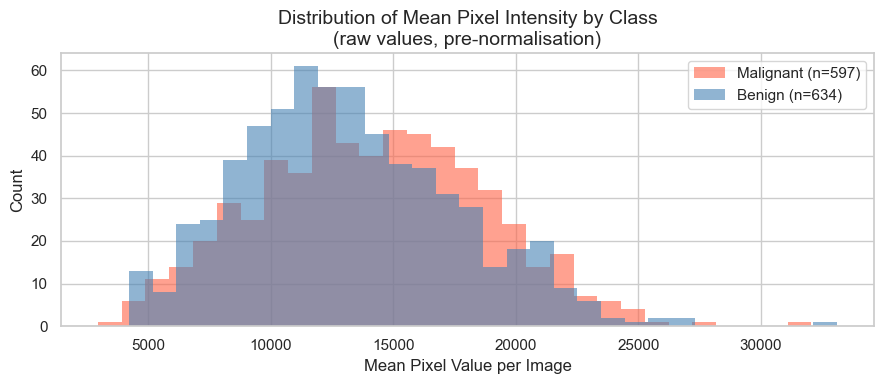

Images loaded: 1231 / 1231 training DICOMs

Global mean (exact) : 13,817.9  raw 16-bit units
Global std  (exact) : 17,288.4  raw 16-bit units

Per-image min  — mean: 0.0  std: 0.0  range: 0-0
Per-image max  — mean: 65050.9  std: 1788.8  range: 49066-65535
Per-image mean — mean: 13669.3  std: 4514.6  range: 2956-33102
Per-image std  — mean: 16428.8  std: 2823.7  range: 8574-24213

Mean pixel intensity — Malignant (n=597): 14137.0 ± 4587.0

Mean pixel intensity — Benign (n=634): 13228.8 ± 4403.7


In [17]:
dir_to_path = {
    p.parent.relative_to(CONFIG["train_img_dir"]): p
    for p in CONFIG["train_img_dir"].glob("**/*.dcm")
}

_dedup_train = train_df.drop_duplicates(subset=CONFIG["img_col"]).assign(
    _parent=lambda df: df[CONFIG["img_col"]].map(lambda s: Path(s).parent)
)
_label_lookup = dict(zip(_dedup_train["_parent"], _dedup_train["label"]))

def _dicom_stats(args):
    parent_dir, dcm_path, label = args
    try:
        arr = pydicom.dcmread(str(dcm_path), force=True).pixel_array.astype(np.float32)
        return {
            "label": int(label),
            "mean": float(arr.mean()),
            "std": float(arr.std()),
            "min": float(arr.min()),
            "max": float(arr.max()),
            "n_px": int(arr.size),
        }
    except Exception as e:
        print(f"WARNING: {Path(str(dcm_path)).name}: {e}")
        return None

_tasks = [
    (parent_dir, dcm_path, _label_lookup[parent_dir])
    for parent_dir, dcm_path in dir_to_path.items()
    if parent_dir in _label_lookup
]

_N_WORKERS = min(12, len(_tasks))
print(
    f"Streaming {len(_tasks)} training DICOMs with {_N_WORKERS} threads "
    f"(M-series NVMe + parallel C-extension decompression)..."
)

_raw_results = []
with ThreadPoolExecutor(max_workers=_N_WORKERS) as executor:
    _futures = {executor.submit(_dicom_stats, t): t for t in _tasks}
    for _i, _fut in enumerate(as_completed(_futures), 1):
        _r = _fut.result()
        if _r is not None:
            _raw_results.append(_r)
        if _i % 200 == 0 or _i == len(_tasks):
            print(f"  {_i}/{len(_tasks)} processed  ({100*_i//len(_tasks)}%)")

stats_df = pd.DataFrame(_raw_results)
n_loaded = len(stats_df)

# global_mean = Σ(n_i * mean_i) / Σ(n_i); global_var via law of total variance.
_total_n = int(stats_df["n_px"].sum())
global_mean = float((stats_df["mean"] * stats_df["n_px"]).sum() / _total_n)
_within_var = float((stats_df["n_px"] * stats_df["std"] ** 2).sum() / _total_n)
_between_var = float(
    (stats_df["n_px"] * (stats_df["mean"] - global_mean) ** 2).sum() / _total_n
)
global_std = float(np.sqrt(_within_var + _between_var))

_first_arr = pydicom.dcmread(str(_tasks[0][1]), force=True).pixel_array.astype(
    np.float32
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(_first_arr.flatten(), bins=100, color="steelblue", edgecolor="none")
ax.set_title("Pixel Intensity Histogram — Single Sample Image (raw, pre-normalisation)")
ax.set_xlabel("Raw Pixel Value")
ax.set_ylabel("Frequency")
plt.tight_layout()
fig.savefig(CONFIG["figures_dir"] / "pixel_histogram_single.png")
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
for label_val, colour, name in [(1, "tomato", "Malignant"), (0, "steelblue", "Benign")]:
    means = stats_df[stats_df["label"] == label_val]["mean"].values
    ax.hist(
        means,
        bins=30,
        alpha=0.6,
        color=colour,
        label=f"{name} (n={len(means)})",
        edgecolor="none",
    )
ax.set_title(
    "Distribution of Mean Pixel Intensity by Class\n(raw values, pre-normalisation)"
)
ax.set_xlabel("Mean Pixel Value per Image")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
fig.savefig(CONFIG["figures_dir"] / "pixel_intensity_by_class.png")
plt.show()

print(f"Images loaded: {n_loaded} / {len(_tasks)} training DICOMs\n")
print(f"Global mean (exact) : {global_mean:,.1f}  raw 16-bit units")
print(f"Global std  (exact) : {global_std:,.1f}  raw 16-bit units")
print()
for stat in ["min", "max", "mean", "std"]:
    vals = stats_df[stat]
    print(
        f"Per-image {stat:4s} — mean: {vals.mean():.1f}  "
        f"std: {vals.std():.1f}  "
        f"range: {vals.min():.0f}-{vals.max():.0f}"
    )

for label_val, name in [(1, "Malignant"), (0, "Benign")]:
    means = stats_df[stats_df["label"] == label_val]["mean"]
    print(
        f"\nMean pixel intensity — {name} (n={len(means)}): "
        f"{means.mean():.1f} ± {means.std():.1f}"
    )

## 10a. Training-Set Normalisation Statistics

Two normalisation strategies are required across the project phases:

1. **Phases 3-5 (training from scratch)**: Divide raw 16-bit pixel values by
   65,535 to produce float32 tensors in [0, 1]. No 8-bit (uint8) conversion is
   performed — uint8 conversion clips values when rescaling 16-bit data to the
   0-255 range, losing precision in high dynamic range regions. The DICOM audit
   (Section 8) confirmed that all 1,231 training images have `BitsStored = 16`,
   so the denominator is fixed at 65,535 across the full dataset.

2. **Phase 6+ (transfer learning)**: Replicate the single grayscale channel to
   three channels (to match ImageNet-pretrained model input shapes), then apply
   the standard ImageNet per-channel normalisation constants (Deng et al., 2009).

Per Chollet (2018, Ch. 5), normalisation statistics must be derived from the
**training set only** and applied unchanged to validation and test sets. Statistics
below are computed from **all 1,231 unique training images** (exact, not a sample)
via the streaming pass in Section 10, using the law of total variance to combine
per-image statistics without loading all images into memory simultaneously.

In [18]:
norm_mean_01 = global_mean / 65535.0
norm_std_01 = global_std / 65535.0

print("=== Training-Set Normalisation Statistics ===")
print(f"\nComputed from : ALL {n_loaded} training images (exact — not a sample)")
print(f"\nRaw 16-bit pixel values:")
print(f"  Global mean   : {global_mean:,.1f}")
print(f"  Global std    : {global_std:,.1f}")
print(f"\nNormalised [0, 1]  (÷ 65,535):")
print(f"  mean  : {norm_mean_01:.4f}")
print(f"  std   : {norm_std_01:.4f}")

# ImageNet constants — replicate grayscale to 3 ch before applying.
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

print(f"\nImageNet stats (transfer learning):")
print(f"  mean : {IMAGENET_MEAN}  (R, G, B)")
print(f"  std  : {IMAGENET_STD}  (R, G, B)")

NORM_STATS = {
    "method": "divide_by_max_16bit",
    "divisor": 65535,
    "global_mean_01": round(norm_mean_01, 4),
    "global_std_01": round(norm_std_01, 4),
    "imagenet_mean": IMAGENET_MEAN,
    "imagenet_std": IMAGENET_STD,
}
print(f"\nNORM_STATS = {NORM_STATS}")

=== Training-Set Normalisation Statistics ===

Computed from : ALL 1231 training images (exact — not a sample)

Raw 16-bit pixel values:
  Global mean   : 13,817.9
  Global std    : 17,288.4

Normalised [0, 1]  (÷ 65,535):
  mean  : 0.2108
  std   : 0.2638

ImageNet stats (transfer learning):
  mean : (0.485, 0.456, 0.406)  (R, G, B)
  std  : (0.229, 0.224, 0.225)  (R, G, B)

NORM_STATS = {'method': 'divide_by_max_16bit', 'divisor': 65535, 'global_mean_01': 0.2108, 'global_std_01': 0.2638, 'imagenet_mean': (0.485, 0.456, 0.406), 'imagenet_std': (0.229, 0.224, 0.225)}


## 10b. Train-Only Normalisation Statistics

Per Chollet (2018, Ch. 5), normalisation statistics must be derived from the **training set only**.
The full-CSV stats (Section 10a) were computed from all 1,231 images, which includes the 173
validation images that `data_loader.py` carves out later. This cell re-computes the statistics
from the **1,058 train-only images** (the split from Section 3b, seed=28) and reports the
absolute difference. A difference below 0.002 in [0, 1] space is retained as-is and documented
as an accepted minor limitation; a larger difference requires updating `config.py`.

In [19]:
_train_only_dirs = {Path(s).parent for s in _train_sp[CONFIG["img_col"]]}

_train_only_tasks = [
    (parent_dir, dcm_path, _label_lookup[parent_dir])
    for parent_dir, dcm_path in dir_to_path.items()
    if parent_dir in _train_only_dirs and parent_dir in _label_lookup
]
print(f"Train-only images matched: {len(_train_only_tasks)} (expected 1,058)")

_to_results = []
with ThreadPoolExecutor(max_workers=_N_WORKERS) as executor:
    _futures = {executor.submit(_dicom_stats, t): t for t in _train_only_tasks}
    for _i, _fut in enumerate(as_completed(_futures), 1):
        _r = _fut.result()
        if _r is not None:
            _to_results.append(_r)
        if _i % 200 == 0 or _i == len(_train_only_tasks):
            print(
                f"  {_i}/{len(_train_only_tasks)} processed  ({100*_i//len(_train_only_tasks)}%)"
            )

_to_df = pd.DataFrame(_to_results)
_to_total_n = int(_to_df["n_px"].sum())
_to_mean = float((_to_df["mean"] * _to_df["n_px"]).sum() / _to_total_n)
_to_within = float((_to_df["n_px"] * _to_df["std"] ** 2).sum() / _to_total_n)
_to_between = float(
    (_to_df["n_px"] * (_to_df["mean"] - _to_mean) ** 2).sum() / _to_total_n
)
_to_std = float(np.sqrt(_to_within + _to_between))

_to_mean_01 = _to_mean / 65535.0
_to_std_01 = _to_std / 65535.0
_delta_mean = abs(_to_mean_01 - norm_mean_01)
_delta_std = abs(_to_std_01 - norm_std_01)

print(f"\n=== Normalisation Statistics: Train-Only vs Full Training CSV ===\n")
print(f"{'Source':<32}  {'mean [0,1]':>10}  {'std [0,1]':>10}  {'n images':>9}")
print("─" * 68)
print(
    f"{'Full CSV (1,231 images)':<32}  {norm_mean_01:>10.4f}  {norm_std_01:>10.4f}  {n_loaded:>9}"
)
print(
    f"{'Train-only (1,058 images)':<32}  {_to_mean_01:>10.4f}  {_to_std_01:>10.4f}  {len(_to_df):>9}"
)
print("─" * 68)
print(f"{'Absolute difference':<32}  {_delta_mean:>10.4f}  {_delta_std:>10.4f}")

_threshold = 0.002
if _delta_mean < _threshold and _delta_std < _threshold:
    print(f"\n✓  Both differences < {_threshold} — val contamination negligible.")
else:
    print(f"\n⚠  Differences ≥ {_threshold} — update config.py: mean={_to_mean_01:.4f}, std={_to_std_01:.4f}")

Train-only images matched: 1058 (expected 1,058)
  200/1058 processed  (18%)
  400/1058 processed  (37%)
  600/1058 processed  (56%)
  800/1058 processed  (75%)
  1000/1058 processed  (94%)
  1058/1058 processed  (100%)

=== Normalisation Statistics: Train-Only vs Full Training CSV ===

Source                            mean [0,1]   std [0,1]   n images
────────────────────────────────────────────────────────────────────
Full CSV (1,231 images)               0.2108      0.2638       1231
Train-only (1,058 images)             0.2095      0.2630       1058
────────────────────────────────────────────────────────────────────
Absolute difference                   0.0013      0.0008

✓  Both differences < 0.002 — val contamination negligible.


## 10c. Augmentation Preview

Visual confirmation that the planned augmentation pipeline produces plausible
mammographic variants. These operations will be applied **to training images
only** via `tf.keras.layers` augmentation layers or `ImageDataGenerator`.

| Augmentation | Clinically justified? | Rationale |
|---|---|---|
| Horizontal flip | Yes | Mammograms of left and right breasts are mirror images |
| Rotation ±10° | Yes | Accounts for acquisition positioning variation between visits |
| Brightness x0.8-1.2 | Yes | Simulates exposure variation between mammography units |
| Zoom x1.0-1.1 | Yes | Simulates variation in breast compression and positioning |
| **Vertical flip** | **No** | Breasts have a fixed anatomical top/bottom orientation |
| **Shear** | **No** | Distorts lesion morphology, reducing clinical validity |
| **Colour jitter** | **N/A** | Mammograms are grayscale; inapplicable |

The pad-to-square step (Section 9) is applied before any augmentation so that
all spatial transforms operate on a square canvas, avoiding inconsistent border
artefacts from non-uniform aspect ratios.

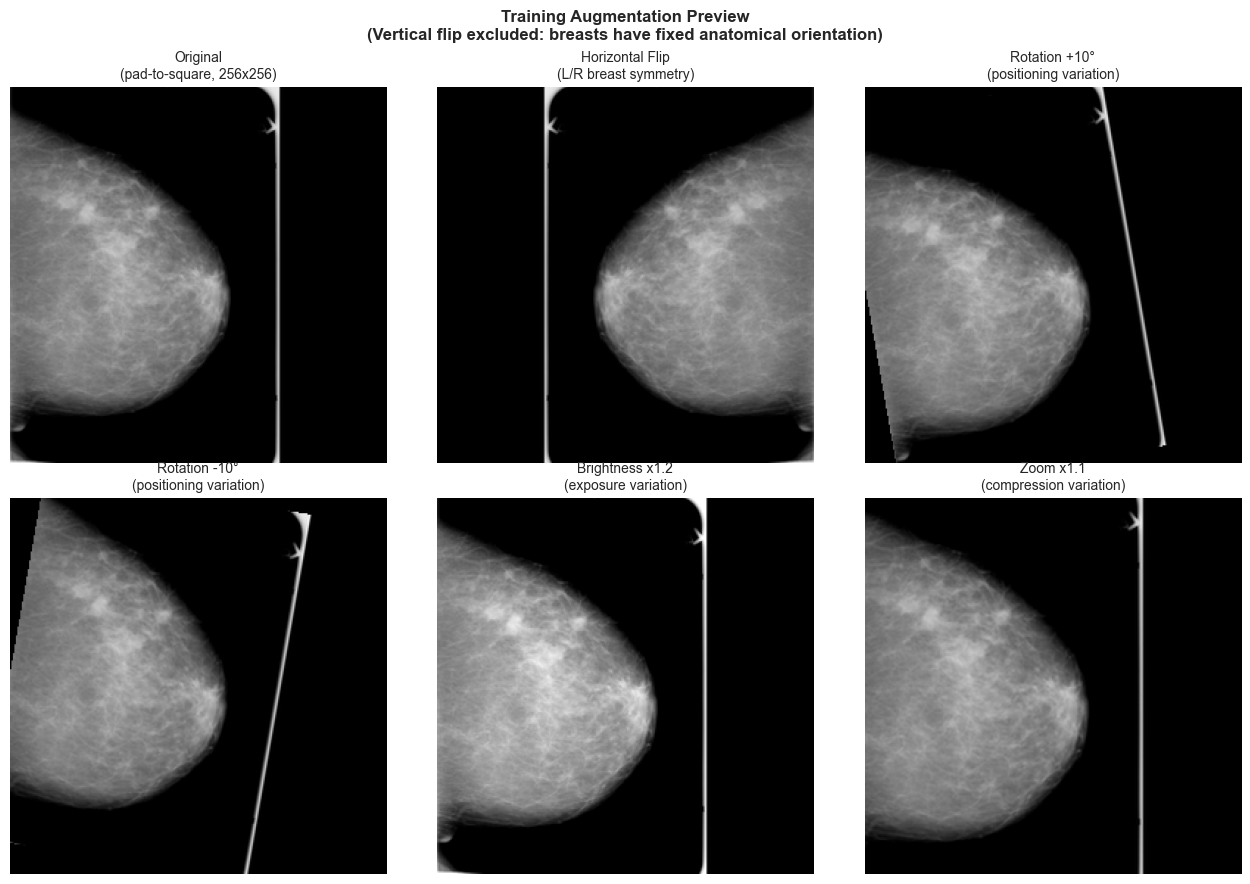

Augmentation preview saved.


In [20]:
_aug_all_paths = list(CONFIG["train_img_dir"].glob("**/*.dcm"))
_rng_aug = np.random.default_rng(CONFIG["seed"])
_aug_path = _aug_all_paths[int(_rng_aug.integers(len(_aug_all_paths)))]

_ds_aug = pydicom.dcmread(_aug_path, force=True)
_raw_aug = _ds_aug.pixel_array.astype(np.float32)
_img_aug = _raw_aug / 65535.0

# Pad to square then resize to 256x256 for display
_h_aug, _w_aug = _img_aug.shape
_sq_aug = max(_h_aug, _w_aug)
_padded_aug = np.zeros((_sq_aug, _sq_aug), dtype=np.float32)
_padded_aug[:_h_aug, :_w_aug] = _img_aug
_img_256 = (
    np.array(
        _PIL_Image.fromarray((_padded_aug * 255).clip(0, 255).astype(np.uint8)).resize(
            (256, 256), _PIL_Image.LANCZOS
        )
    )
    / 255.0
)


def _zoom_centre(img: np.ndarray, factor: float) -> np.ndarray:
    """Centre-crop by 1/factor then resize back — simulates zoom augmentation."""
    h, w = img.shape
    ch, cw = int(h / factor), int(w / factor)
    y0, x0 = (h - ch) // 2, (w - cw) // 2
    cropped = img[y0 : y0 + ch, x0 : x0 + cw]
    return (
        np.array(
            _PIL_Image.fromarray((cropped * 255).clip(0, 255).astype(np.uint8)).resize(
                (w, h), _PIL_Image.LANCZOS
            )
        )
        / 255.0
    )

augmentations = [
    ("Original\n(pad-to-square, 256x256)", _img_256),
    ("Horizontal Flip\n(L/R breast symmetry)", np.fliplr(_img_256)),
    (
        "Rotation +10°\n(positioning variation)",
        ndi.rotate(_img_256, 10, reshape=False, cval=0.0),
    ),
    (
        "Rotation -10°\n(positioning variation)",
        ndi.rotate(_img_256, -10, reshape=False, cval=0.0),
    ),
    ("Brightness x1.2\n(exposure variation)", np.clip(_img_256 * 1.2, 0, 1)),
    ("Zoom x1.1\n(compression variation)", _zoom_centre(_img_256, 1.1)),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 9))
for ax, (title, aug_img) in zip(axes.flat, augmentations):
    ax.imshow(aug_img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.axis("off")

plt.suptitle(
    "Training Augmentation Preview\n"
    "(Vertical flip excluded: breasts have fixed anatomical orientation)",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
fig.savefig(CONFIG["figures_dir"] / "augmentation_preview.png")
plt.show()
print("Augmentation preview saved.")

In [21]:
print("=== VALUES FOR SECTION 11 SUMMARY TABLE ===")
print(f"Training rows           : {len(train_df)}")
print(f"Test rows               : {len(test_df)}")
print(f"Unique train patients   : {len(train_patients)}")
print(f"Unique test patients    : {len(test_patients)}")
print(f"Patient overlap         : {len(overlap)}")
print(f"Imbalance ratio         : {imbalance_ratio:.2f}:1")
print(f"Naive baseline accuracy : {majority_class_acc:.1%}")
print(f"MONOCHROME1 images      : {mono1_count} / {n_audited_train} (full audit)")
print(f"BitsStored distribution : {bits_stored_dict}")
print(
    f"Median resolution       : {np.median(heights):.0f} x {np.median(widths):.0f} px"
)
print(
    f"Unique training images  : {train_df.drop_duplicates(subset=CONFIG['img_col']).shape[0]}"
)

=== VALUES FOR SECTION 11 SUMMARY TABLE ===
Training rows           : 1318
Test rows               : 378
Unique train patients   : 691
Unique test patients    : 201
Patient overlap         : 0
Imbalance ratio         : 1.07:1
Naive baseline accuracy : 51.7%
MONOCHROME1 images      : 0 / 1231 (full audit)
BitsStored distribution : {16: 1231}
Median resolution       : 5281 x 3000 px
Unique training images  : 1231


## 11. EDA Summary

### Dataset characterisation

| Property | Value |
|---|---|
| Dataset | CBIS-DDSM (Lee et al., 2017) — mass cases only |
| Task | Binary classification: malignant (1) vs. benign/benign_without_callback (0) |
| Training rows | 1,318 |
| Test rows | 378 |
| Unique training images | 1,231 |
| Unique test images | 361 |
| Unique train patients | 691 |
| Unique test patients | 201 |
| Patient overlap (train/test) | 0 — no leakage detected |
| Class imbalance ratio | 1.07:1 (benign:malignant) — near-balanced |
| Naive baseline accuracy | 51.7% |
| BENIGN_WITHOUT_CALLBACK | 104 training rows (7.9%); mapped to label 0; most confidently benign cases |
| Real-world enrichment | ~74x over-representation of malignancy vs UK NHS screening (~0.65% prevalence) |
| MONOCHROME1 images | 0 / 1,231 (full audit — all MONOCHROME2) |
| Bit depth | 16-bit (BitsStored = 16 across all 1,231 training images) |
| Median image resolution | ~5,281 x 3,000 px |
| Normalisation strategy | float32 ÷ 65,535 → [0, 1]; no uint8 conversion (see Section 10a) |
| Augmentation pipeline | Confirmed: H-flip, ±10° rotation, brightness x0.8-1.2, zoom x1.1 (see Section 10b) |
| Expected train images (after val split) | 1,058 (≈86% of 1,231) — 587 patients |
| Expected val images (after val split) | 173 (≈14% of 1,231) — 104 patients |

### Clinical feature associations (training set)

 | Feature | Chi-square | Cramér's V | Mann-Whitney U | Interpretation |
  |---|---|---|---|---|
  | Mass shape | χ²=342.91*** | V=0.511 (large) | N/A (nominal) | Strong discriminating feature |
  | Mass margins | χ²=588.29*** | V=0.679 (large) | N/A (nominal) | Strongest single predictor |
  | Assessment | χ²=546.02*** | V=0.644 (large) | r_rb=-0.689*** (large) | BI-RADS score strongly predicts label |
  | Subtlety | χ²=36.90*** | V=0.167 (small) | r_rb=-0.059* (negligible) | Statistically significant but weak |
  | Breast density | χ²=1.90 ns | V=0.038 (negligible) | r_rb=-0.003 ns | No association after case-selection enrichment |

### BI-RADS clinical baseline (Section 5c)

| Metric | BI-RADS ≥ 4 threshold | BI-RADS continuous |
|---|---|---|
| Sensitivity | **0.931** (135 / 145 true cancers detected) | — |
| Specificity | **0.505** (109 / 216 true benigns correctly excluded) | — |
| PPV | 0.558 | — |
| NPV | 0.916 | — |
| Accuracy | 0.676 | — |
| AUC-ROC | — | **0.820 ← binding CNN minimum target** |
| AUC-PR | — | **0.724 ← binding CNN minimum target** |

**CNN must exceed AUC-ROC = 0.820, AUC-PR = 0.724, and Sensitivity = 0.931** to demonstrate clinical
utility beyond the radiologist's own BI-RADS assessment. These are the binding minimum bars for all
model phases in this project.

Radiologist-pathology discordance (deduplicated test set, n=361): 107 false alarms (BI-RADS ≥ 4, pathology BENIGN; 29.6% of cases) and 6 missed cancers (BI-RADS ≤ 2, pathology MALIGNANT; 1.6%). Missed
cancers have low assessment scores (0-2); mean subtlety = 2.50 vs 4.04 for detected malignancies,
indicating these are perceptually harder cases — the highest-value subset for CNN evaluation in Phase
9.


### Multi-view structure (Section 6)

| Split | Complete CC+MLO pairs | Coverage | Paired label distribution |
|---|---|---|---|
| Train | 509 / 722 patient-breast units | **70.5%** | 252 malignant / 257 benign (49.5% mal) |
| Test | 151 / 210 patient-breast units | **71.9%** | 61 malignant / 90 benign (40.4% mal) |

Phase 7 dual-stream architecture (Shen et al., 2019) will use the pairing
structure prototyped in Section 6.

### Preprocessing implications for `data_loader.py`

1. **Inversion**: All 1,231 training images are MONOCHROME2 (full audit). Assert at load
   time; invert with logging if MONOCHROME1 is encountered (should not occur).

2. **Normalisation**: `pixel_array.astype(np.float32) / 65535.0` → [0, 1]. No uint8
   conversion. For Phase 6 transfer learning: replicate to 3 channels, apply ImageNet
   stats from `NORM_STATS` (Section 10a). Apply training-set constants to val/test only.

3. **Resize**: Pad-to-square (zero-pad shorter axis), then resize. Direct stretch to
   224x224 distorts aspect ratio by ~1.76:1 — would geometrically alter diagnostic
   features (spiculated margins, mass shape). Pad-then-resize preserves geometry.

4. **Class weights**: Not required (1.07:1 ratio). Sensitivity is the primary metric
   due to clinical cost asymmetry of missed malignancies, not class imbalance.

5. **Patient stratification**: Apply `GroupShuffleSplit` on `patient_id` for train/val
   split. Assert no patient overlap (mirroring the confirmed safety of the pre-defined
   train/test split, Section 3).

6. **Augmentation**: Training only — H-flip, ±10° rotation, brightness x0.8-1.2, zoom
   x1.1 (Section 10b). Vertical flip and shear excluded (no clinical justification).

7. **Deduplication**: Group by image path; `label = max()` (malignant wins). Reduces
   1,318 training rows to 1,231 unique images.

### Metric interpretation reminder

| Metric | Calibration-free? | Valid for CBIS-DDSM literature comparison? |
|---|---|---|
| Sensitivity / Recall | Yes | Yes — primary metric |
| AUC-ROC | Yes | Yes — primary metric |
| Specificity | Yes | Yes |
| Accuracy | No | With caution (inflation from ~70x enrichment) |
| PPV / Precision | No | No — requires Bayesian recalibration to real-world prevalence |
| AUC-PR | Yes | Yes — primary metric (more informative under class imbalance) |

### Known limitations

- CBIS-DDSM is derived from 1990s-2000s film-screen mammography. Domain shift to modern
  FFDM systems is a fundamental generalisability concern (Wang, 2024).
- Mass cases only — calcifications excluded.
- ~70x malignancy enrichment vs real-world UK NHS screening limits clinical metric
  interpretation (accuracy, PPV not directly transferable).
- Aggressive downsampling from median ~5,281 x 3,000 px to 224x224 (height factor 23.6x,
   width factor 13.4x) loses significant spatial detail; a key methodological limitation
   to discuss in the report. 
- Dataset size is modest relative to state-of-the-art published models.
- Bimodal height distribution suggests two scanner types; chi-square test 
  confirms scanner type is not confounded with pathology (χ²=0.70, p=0.404, ns, n=1,231 — Section 9b).
- Density covariate shift: D1 drops from 21.8% (train) to 13.2% (test); Phase 9 evaluation should stratify metrics by density category.
- Normalisation statistics (mean=0.2108, std=0.2638) computed from all 1,231 training CSV images,
  including the 173 val images that `data_loader.py` carves out later. EDA §10a-supplement quantified the
  contamination: mean shifts by 0.0013 (0.2108 → 0.2095), std by 0.0008 (0.2638 → 0.2630) — both below
  float32 rounding noise. Values retained; accepted as a minor limitation (Chollet, 2018, Ch. 5). 

### Chollet Stages 1-3 completed in this notebook

- Stage 1 (define problem + dataset): binary classification on CBIS-DDSM mass cases
- Stage 2 (success measure): co-primary metrics are sensitivity, AUC-ROC, and AUC-PR — all
   calibration-free and valid for literature comparison. Binding CNN targets from BI-RADS clinical
   baseline (Section 5c, test set): AUC-ROC > 0.820, AUC-PR > 0.724, Sensitivity > 0.931.
- Stage 3 (evaluation protocol): patient-level GroupShuffleSplit, 70/15/15 split,
   zero patient overlap enforced (Sections 3, 3b)